### Num Ops Vs Threads

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
orig_2by2 = np.load("2by2_num_ops_vs_threads_orig.npz", allow_pickle=True)
orig_4by4 = np.load("4by4_num_ops_vs_threads_orig.npz", allow_pickle=True)
orig_6by6 = np.load("6by6_num_ops_vs_threads_orig.npz", allow_pickle=True)
ops16_4by4 = np.load("4by4_num_ops_vs_threads_16.npz", allow_pickle=True)
ops16_6by6 = np.load("6by6_num_ops_vs_threads_16.npz", allow_pickle=True)
ops56_6by6 = np.load("6by6_num_ops_vs_threads_56.npz", allow_pickle=True)

data_list = [orig_2by2, orig_4by4, orig_6by6, ops16_4by4, ops16_6by6, ops56_6by6]
name_list = ['2by2', '4by4', '6by6', '4by4_16', '6by6_16', '6by6_56']

leg_max_order = 10
max_time_back_seconds = 1
max_timesteps_back = np.rint(250*max_time_back_seconds).astype(int)
leg_x = np.linspace(1, leg_max_order, leg_max_order)
mem_x = np.linspace(0, max_time_back_seconds, max_timesteps_back+1)

# Extract data for plotting
data_dict = {}
for data, name in zip(data_list, name_list):
    leg_cap_test = data['legendre_cap'][1]
    mem_cap_test = data['memory_cap'][1]
    data_dict[name] = {'legendre_cap': leg_cap_test, 'memory_cap': mem_cap_test}

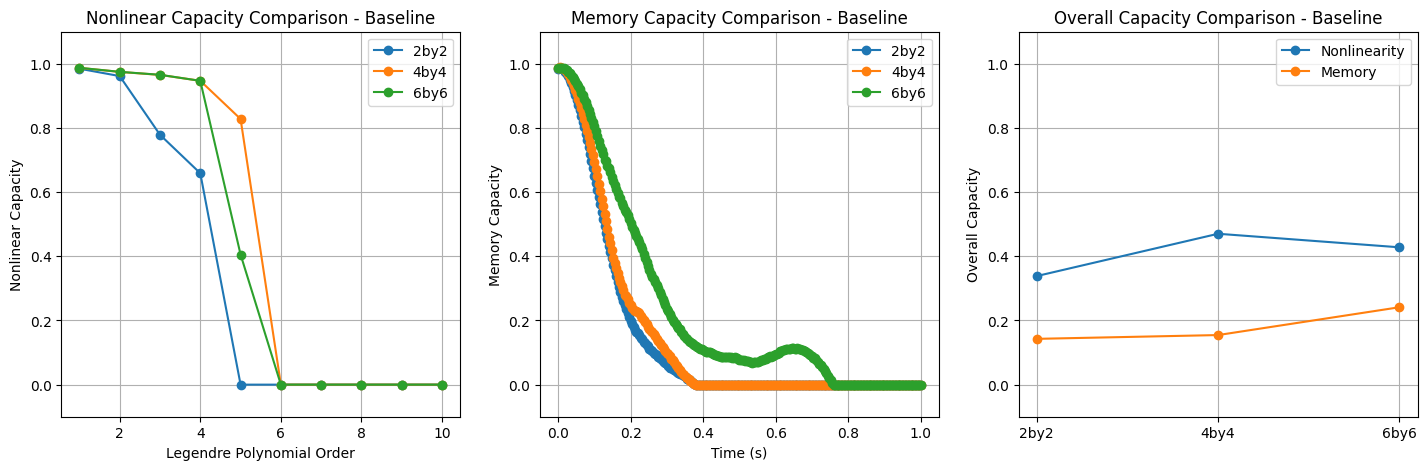

In [2]:
# Baseline Comparison between densities
plt.figure(figsize=(17.5, 5))
plt.subplot(131)
plt.plot(leg_x, data_dict['2by2']['legendre_cap'], '-o', label='2by2')
plt.plot(leg_x, data_dict['4by4']['legendre_cap'], '-o', label='4by4')
plt.plot(leg_x, data_dict['6by6']['legendre_cap'], '-o', label='6by6')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear Capacity')
plt.title('Nonlinear Capacity Comparison - Baseline')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_dict['2by2']['memory_cap'], '-o', label='2by2')
plt.plot(mem_x, data_dict['4by4']['memory_cap'], '-o', label='4by4')
plt.plot(mem_x, data_dict['6by6']['memory_cap'], '-o', label='6by6')
plt.xlabel('Time (s)')
plt.ylabel('Memory Capacity')
plt.title('Memory Capacity Comparison - Baseline')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = ['2by2', '4by4', '6by6']
onl_list = [sum(data_dict['2by2']['legendre_cap'])/len(data_dict['2by2']['legendre_cap']),
            sum(data_dict['4by4']['legendre_cap'])/len(data_dict['4by4']['legendre_cap']),
            sum(data_dict['6by6']['legendre_cap'])/len(data_dict['6by6']['legendre_cap'])]
oml_list = [sum(data_dict['2by2']['memory_cap'])/len(data_dict['2by2']['memory_cap']),
            sum(data_dict['4by4']['memory_cap'])/len(data_dict['4by4']['memory_cap']),
            sum(data_dict['6by6']['memory_cap'])/len(data_dict['6by6']['memory_cap'])]
plt.plot(labels_list, onl_list, '-o', label='Nonlinearity')
plt.plot(labels_list, oml_list, '-o', label='Memory')
plt.ylabel('Overall Capacity')
plt.title('Overall Capacity Comparison - Baseline')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.show()

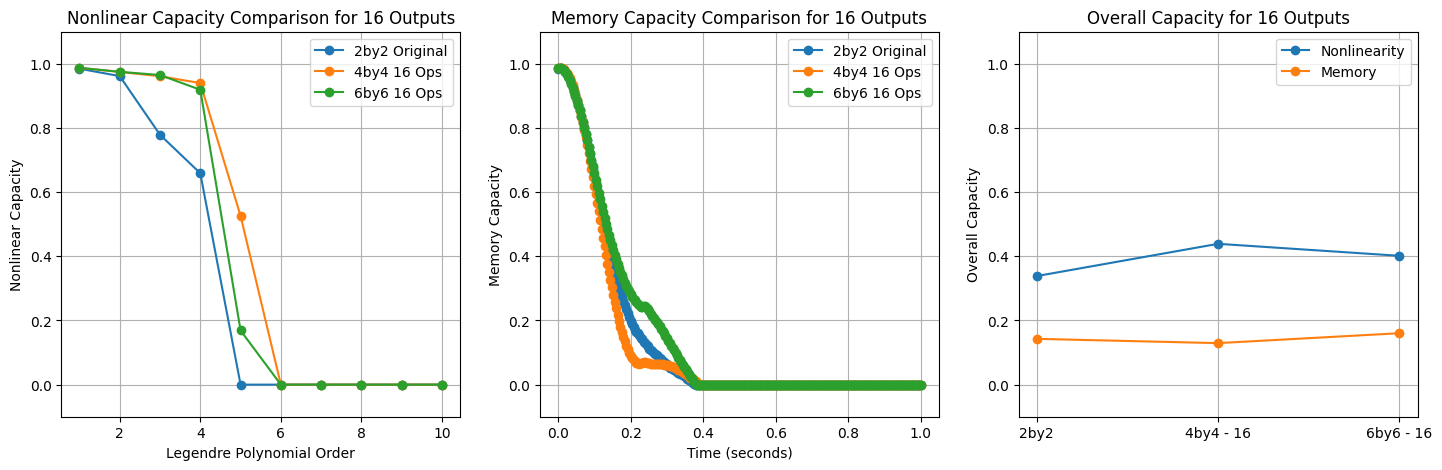

In [3]:
# 2by2 vs 16 ops from 4by4 vs 16 ops from 6by6
plt.figure(figsize=(17.5, 5))
plt.subplot(131)
plt.plot(leg_x, data_dict['2by2']['legendre_cap'], '-o', label='2by2 Original')
plt.plot(leg_x, data_dict['4by4_16']['legendre_cap'], '-o', label='4by4 16 Ops')
plt.plot(leg_x, data_dict['6by6_16']['legendre_cap'], '-o', label='6by6 16 Ops')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear Capacity')
plt.title('Nonlinear Capacity Comparison for 16 Outputs')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(132)
plt.plot(mem_x, data_dict['2by2']['memory_cap'], '-o', label='2by2 Original')
plt.plot(mem_x, data_dict['4by4_16']['memory_cap'], '-o', label='4by4 16 Ops')
plt.plot(mem_x, data_dict['6by6_16']['memory_cap'], '-o', label='6by6 16 Ops')
plt.xlabel('Time (seconds)')
plt.ylabel('Memory Capacity')
plt.title('Memory Capacity Comparison for 16 Outputs')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(133)
labels_list = ['2by2', '4by4 - 16', '6by6 - 16']
onl_list = [sum(data_dict['2by2']['legendre_cap'])/len(data_dict['2by2']['legendre_cap']),
            sum(data_dict['4by4_16']['legendre_cap'])/len(data_dict['4by4_16']['legendre_cap']),
            sum(data_dict['6by6_16']['legendre_cap'])/len(data_dict['6by6_16']['legendre_cap'])]
oml_list = [sum(data_dict['2by2']['memory_cap'])/len(data_dict['2by2']['memory_cap']),
            sum(data_dict['4by4_16']['memory_cap'])/len(data_dict['4by4_16']['memory_cap']),
            sum(data_dict['6by6_16']['memory_cap'])/len(data_dict['6by6_16']['memory_cap'])]
plt.plot(labels_list, onl_list, '-o', label='Nonlinearity')
plt.plot(labels_list, oml_list, '-o', label='Memory')
plt.ylabel('Overall Capacity')
plt.title('Overall Capacity for 16 Outputs')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.show()

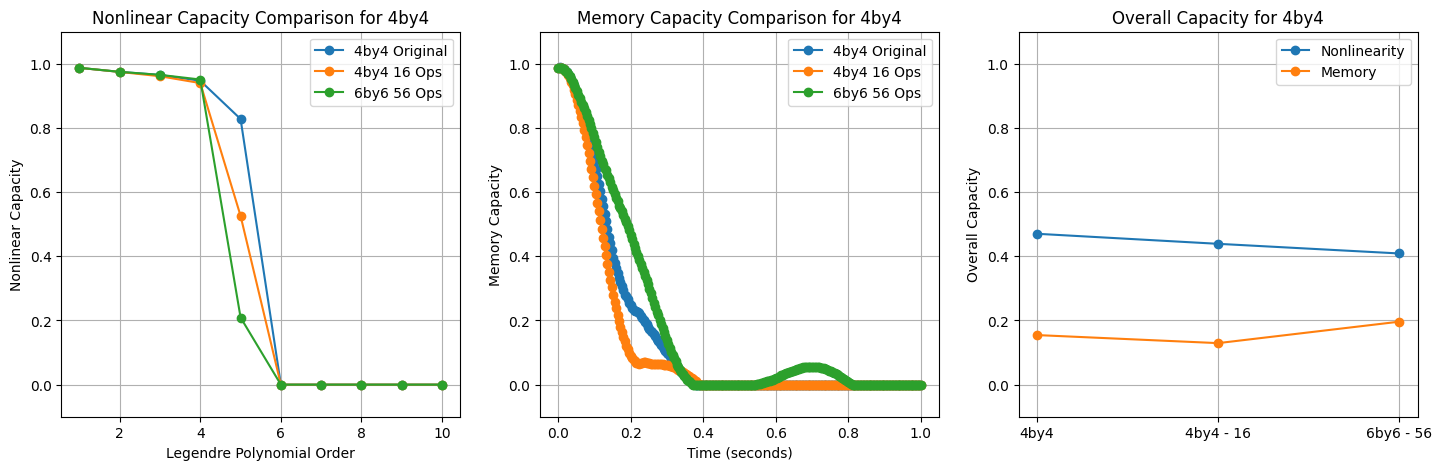

In [9]:
# 4by4 vs 56 ops from 6by6
plt.figure(figsize=(17.5, 5))
plt.subplot(131)
plt.plot(leg_x, data_dict['4by4']['legendre_cap'], '-o', label='4by4 Original')
plt.plot(leg_x, data_dict['4by4_16']['legendre_cap'], '-o', label='4by4 16 Ops')
plt.plot(leg_x, data_dict['6by6_56']['legendre_cap'], '-o', label='6by6 56 Ops')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear Capacity')
plt.title('Nonlinear Capacity Comparison for 4by4')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(132)
plt.plot(mem_x, data_dict['4by4']['memory_cap'], '-o', label='4by4 Original')
plt.plot(mem_x, data_dict['4by4_16']['memory_cap'], '-o', label='4by4 16 Ops')
plt.plot(mem_x, data_dict['6by6_56']['memory_cap'], '-o', label='6by6 56 Ops')
plt.xlabel('Time (seconds)')
plt.ylabel('Memory Capacity')
plt.title('Memory Capacity Comparison for 4by4')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(133)
labels_list = ['4by4', '4by4 - 16', '6by6 - 56']
onl_list = [sum(data_dict['4by4']['legendre_cap'])/len(data_dict['4by4']['legendre_cap']),
            sum(data_dict['4by4_16']['legendre_cap'])/len(data_dict['4by4_16']['legendre_cap']),
            sum(data_dict['6by6_56']['legendre_cap'])/len(data_dict['6by6_56']['legendre_cap'])]
oml_list = [sum(data_dict['4by4']['memory_cap'])/len(data_dict['4by4']['memory_cap']),
            sum(data_dict['4by4_16']['memory_cap'])/len(data_dict['4by4_16']['memory_cap']),
            sum(data_dict['6by6_56']['memory_cap'])/len(data_dict['6by6_56']['memory_cap'])]
plt.plot(labels_list, onl_list, '-o', label='Nonlinearity')
plt.plot(labels_list, oml_list, '-o', label='Memory')
plt.ylabel('Overall Capacity')
plt.title('Overall Capacity for 4by4')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.show()

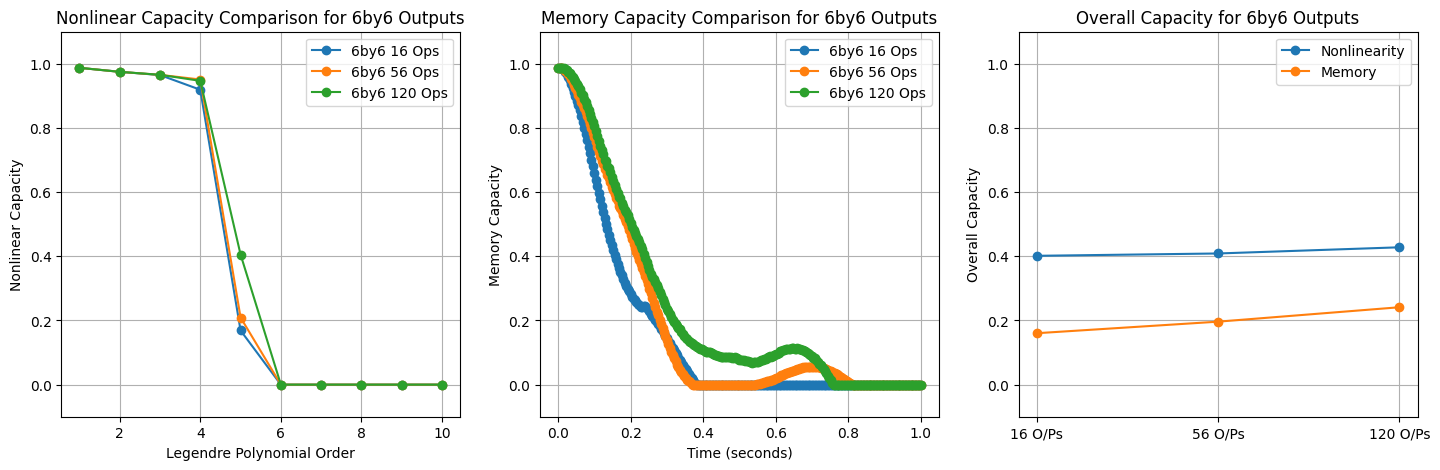

In [6]:
# 6by6 16 vs 56 vs 120 ops
plt.figure(figsize=(17.5, 5))
plt.subplot(131)
plt.plot(leg_x, data_dict['6by6_16']['legendre_cap'], '-o', label='6by6 16 Ops')
plt.plot(leg_x, data_dict['6by6_56']['legendre_cap'], '-o', label='6by6 56 Ops')
plt.plot(leg_x, data_dict['6by6']['legendre_cap'], '-o', label='6by6 120 Ops')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear Capacity')
plt.title('Nonlinear Capacity Comparison for 6by6 Outputs')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(132)
plt.plot(mem_x, data_dict['6by6_16']['memory_cap'], '-o', label='6by6 16 Ops')
plt.plot(mem_x, data_dict['6by6_56']['memory_cap'], '-o', label='6by6 56 Ops')
plt.plot(mem_x, data_dict['6by6']['memory_cap'], '-o', label='6by6 120 Ops')
plt.xlabel('Time (seconds)')
plt.ylabel('Memory Capacity')
plt.title('Memory Capacity Comparison for 6by6 Outputs')
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid()

plt.subplot(133)
labels_list = ['16 O/Ps', '56 O/Ps', '120 O/Ps']
onl_list = [sum(data_dict['6by6_16']['legendre_cap'])/len(data_dict['6by6_16']['legendre_cap']),
            sum(data_dict['6by6_56']['legendre_cap'])/len(data_dict['6by6_56']['legendre_cap']),
            sum(data_dict['6by6']['legendre_cap'])/len(data_dict['6by6']['legendre_cap'])]
oml_list = [sum(data_dict['6by6_16']['memory_cap'])/len(data_dict['6by6_16']['memory_cap']),
            sum(data_dict['6by6_56']['memory_cap'])/len(data_dict['6by6_56']['memory_cap']),
            sum(data_dict['6by6']['memory_cap'])/len(data_dict['6by6']['memory_cap'])]
plt.plot(labels_list, onl_list, '-o', label='Nonlinearity')
plt.plot(labels_list, oml_list, '-o', label='Memory')
plt.ylabel('Overall Capacity')
plt.title('Overall Capacity for 6by6 Outputs')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.show()

### Num Ops

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
orig = np.load("6by6_num_ops_vs_threads_orig.npz", allow_pickle=True)
conns = np.load("6by6_ops_conns.npz", allow_pickle=True)
hors = np.load("6by6_ops_hors.npz", allow_pickle=True)
hors_no_act = np.load("6by6_ops_hors_no_act.npz", allow_pickle=True)
vers = np.load("6by6_ops_vers.npz", allow_pickle=True)
conns_hors = np.load("6by6_ops_conns_hors.npz", allow_pickle=True)
conns_vers = np.load("6by6_ops_conns_vers.npz", allow_pickle=True)
hors_vers = np.load("6by6_ops_hors_vers.npz", allow_pickle=True)
hors_vers_no_act = np.load("6by6_ops_hors_vers_no_act.npz", allow_pickle=True)

data_list = [orig, conns, hors, hors_no_act, vers, conns_hors, conns_vers, hors_vers, hors_vers_no_act]
name_list = ['orig', 'conns', 'hors', 'hors_no_act', 'vers', 'conns_hors', 'conns_vers', 'hors_vers', 'hors_vers_no_act']

leg_max_order = 10
max_time_back_seconds = 1
max_timesteps_back = np.rint(250*max_time_back_seconds).astype(int)
leg_x = np.linspace(1, leg_max_order, leg_max_order)
mem_x = np.linspace(0, max_time_back_seconds, max_timesteps_back+1)

# Extract data for plotting
data_dict = {}
for data, name in zip(data_list, name_list):
    leg_cap_test = data['legendre_cap'][1]
    mem_cap_test = data['memory_cap'][1]
    data_dict[name] = {'legendre_cap': leg_cap_test, 'memory_cap': mem_cap_test}

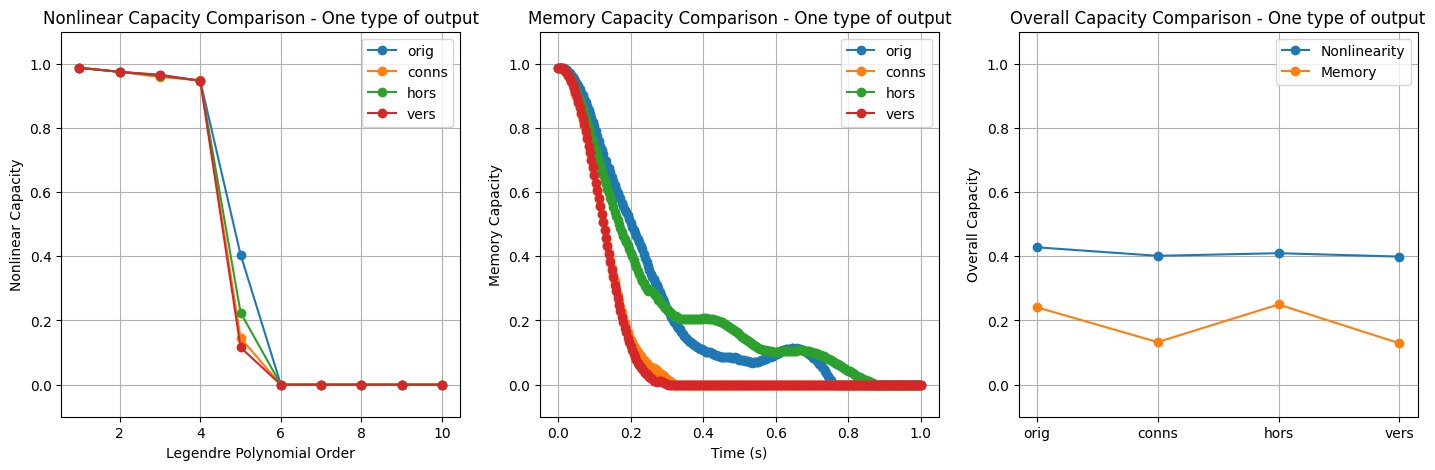

In [2]:
# One type
plt.figure(figsize=(17.5, 5))
plt.subplot(131)
plt.plot(leg_x, data_dict['orig']['legendre_cap'], '-o', label='orig')
plt.plot(leg_x, data_dict['conns']['legendre_cap'], '-o', label='conns')
plt.plot(leg_x, data_dict['hors']['legendre_cap'], '-o', label='hors')
plt.plot(leg_x, data_dict['vers']['legendre_cap'], '-o', label='vers')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear Capacity')
plt.title('Nonlinear Capacity Comparison - One type of output')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_dict['orig']['memory_cap'], '-o', label='orig')
plt.plot(mem_x, data_dict['conns']['memory_cap'], '-o', label='conns')
plt.plot(mem_x, data_dict['hors']['memory_cap'], '-o', label='hors')
plt.plot(mem_x, data_dict['vers']['memory_cap'], '-o', label='vers')
plt.xlabel('Time (s)')
plt.ylabel('Memory Capacity')
plt.title('Memory Capacity Comparison - One type of output')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = ['orig', 'conns', 'hors', 'vers']
onl_list = [sum(data_dict['orig']['legendre_cap'])/len(data_dict['orig']['legendre_cap']),
            sum(data_dict['conns']['legendre_cap'])/len(data_dict['conns']['legendre_cap']),
            sum(data_dict['hors']['legendre_cap'])/len(data_dict['hors']['legendre_cap']),
            sum(data_dict['vers']['legendre_cap'])/len(data_dict['vers']['legendre_cap'])]
oml_list = [sum(data_dict['orig']['memory_cap'])/len(data_dict['orig']['memory_cap']),
            sum(data_dict['conns']['memory_cap'])/len(data_dict['conns']['memory_cap']),
            sum(data_dict['hors']['memory_cap'])/len(data_dict['hors']['memory_cap']),
            sum(data_dict['vers']['memory_cap'])/len(data_dict['vers']['memory_cap'])]
plt.plot(labels_list, onl_list, '-o', label='Nonlinearity')
plt.plot(labels_list, oml_list, '-o', label='Memory')
plt.ylabel('Overall Capacity')
plt.title('Overall Capacity Comparison - One type of output')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.show()

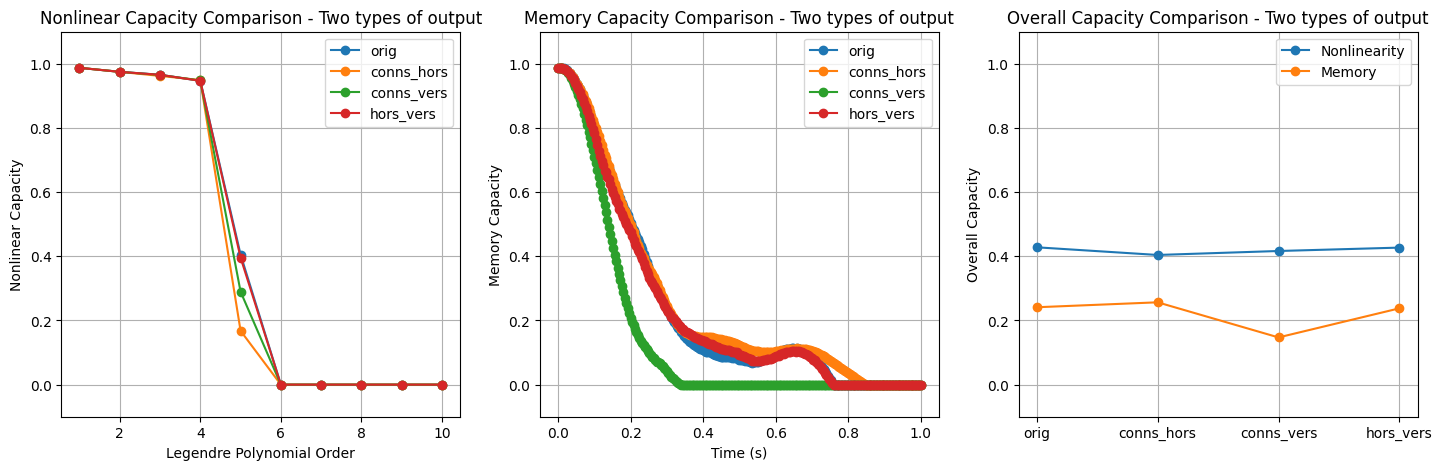

In [3]:
# Two types
plt.figure(figsize=(17.5, 5))
plt.subplot(131)
plt.plot(leg_x, data_dict['orig']['legendre_cap'], '-o', label='orig')
plt.plot(leg_x, data_dict['conns_hors']['legendre_cap'], '-o', label='conns_hors')
plt.plot(leg_x, data_dict['conns_vers']['legendre_cap'], '-o', label='conns_vers')
plt.plot(leg_x, data_dict['hors_vers']['legendre_cap'], '-o', label='hors_vers')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear Capacity')
plt.title('Nonlinear Capacity Comparison - Two types of output')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_dict['orig']['memory_cap'], '-o', label='orig')
plt.plot(mem_x, data_dict['conns_hors']['memory_cap'], '-o', label='conns_hors')
plt.plot(mem_x, data_dict['conns_vers']['memory_cap'], '-o', label='conns_vers')
plt.plot(mem_x, data_dict['hors_vers']['memory_cap'], '-o', label='hors_vers')
plt.xlabel('Time (s)')
plt.ylabel('Memory Capacity')
plt.title('Memory Capacity Comparison - Two types of output')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = ['orig', 'conns_hors', 'conns_vers', 'hors_vers']
onl_list = [sum(data_dict['orig']['legendre_cap'])/len(data_dict['orig']['legendre_cap']),
            sum(data_dict['conns_hors']['legendre_cap'])/len(data_dict['conns_hors']['legendre_cap']),
            sum(data_dict['conns_vers']['legendre_cap'])/len(data_dict['conns_vers']['legendre_cap']),
            sum(data_dict['hors_vers']['legendre_cap'])/len(data_dict['hors_vers']['legendre_cap'])]
oml_list = [sum(data_dict['orig']['memory_cap'])/len(data_dict['orig']['memory_cap']),
            sum(data_dict['conns_hors']['memory_cap'])/len(data_dict['conns_hors']['memory_cap']),
            sum(data_dict['conns_vers']['memory_cap'])/len(data_dict['conns_vers']['memory_cap']),
            sum(data_dict['hors_vers']['memory_cap'])/len(data_dict['hors_vers']['memory_cap'])]
plt.plot(labels_list, onl_list, '-o', label='Nonlinearity')
plt.plot(labels_list, oml_list, '-o', label='Memory')
plt.ylabel('Overall Capacity')
plt.title('Overall Capacity Comparison - Two types of output')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.show()

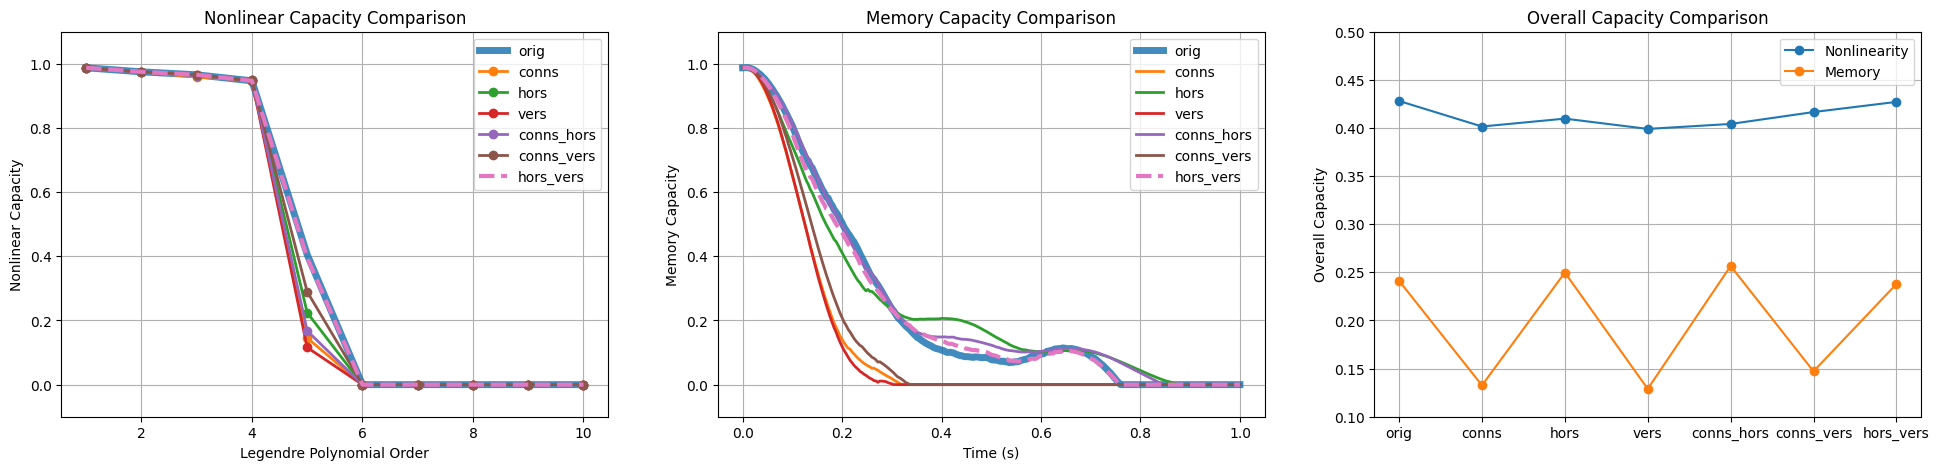

In [24]:
# All
plt.figure(figsize=(24, 5))
plt.subplot(131)
plt.plot(leg_x, data_dict['orig']['legendre_cap'], lw=5, label='orig', alpha=0.85)
plt.plot(leg_x, data_dict['conns']['legendre_cap'], '-o', lw=2, label='conns')
plt.plot(leg_x, data_dict['hors']['legendre_cap'], '-o', lw=2, label='hors')
plt.plot(leg_x, data_dict['vers']['legendre_cap'], '-o', lw=2, label='vers')
plt.plot(leg_x, data_dict['conns_hors']['legendre_cap'], '-o', lw=2, label='conns_hors')
plt.plot(leg_x, data_dict['conns_vers']['legendre_cap'], '-o', lw=2, label='conns_vers')
plt.plot(leg_x, data_dict['hors_vers']['legendre_cap'], '--', lw=3, label='hors_vers')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear Capacity')
plt.title('Nonlinear Capacity Comparison')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_dict['orig']['memory_cap'], lw=5, label='orig', alpha=0.85)
plt.plot(mem_x, data_dict['conns']['memory_cap'], lw=2, label='conns')
plt.plot(mem_x, data_dict['hors']['memory_cap'], lw=2, label='hors')
plt.plot(mem_x, data_dict['vers']['memory_cap'], lw=2, label='vers')
plt.plot(mem_x, data_dict['conns_hors']['memory_cap'], lw=2, label='conns_hors')
plt.plot(mem_x, data_dict['conns_vers']['memory_cap'], lw=2, label='conns_vers')
plt.plot(mem_x, data_dict['hors_vers']['memory_cap'], '--', lw=3, label='hors_vers')
plt.xlabel('Time (s)')
plt.ylabel('Memory Capacity')
plt.title('Memory Capacity Comparison')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = ['orig', 'conns', 'hors', 'vers', 'conns_hors', 'conns_vers', 'hors_vers']
onl_list = [sum(data_dict['orig']['legendre_cap'])/len(data_dict['orig']['legendre_cap']),
            sum(data_dict['conns']['legendre_cap'])/len(data_dict['conns']['legendre_cap']),
            sum(data_dict['hors']['legendre_cap'])/len(data_dict['hors']['legendre_cap']),
            sum(data_dict['vers']['legendre_cap'])/len(data_dict['vers']['legendre_cap']),
            sum(data_dict['conns_hors']['legendre_cap'])/len(data_dict['conns_hors']['legendre_cap']),
            sum(data_dict['conns_vers']['legendre_cap'])/len(data_dict['conns_vers']['legendre_cap']),
            sum(data_dict['hors_vers']['legendre_cap'])/len(data_dict['hors_vers']['legendre_cap'])]
oml_list = [sum(data_dict['orig']['memory_cap'])/len(data_dict['orig']['memory_cap']),
            sum(data_dict['conns']['memory_cap'])/len(data_dict['conns']['memory_cap']),
            sum(data_dict['hors']['memory_cap'])/len(data_dict['hors']['memory_cap']),
            sum(data_dict['vers']['memory_cap'])/len(data_dict['vers']['memory_cap']),
            sum(data_dict['conns_hors']['memory_cap'])/len(data_dict['conns_hors']['memory_cap']),
            sum(data_dict['conns_vers']['memory_cap'])/len(data_dict['conns_vers']['memory_cap']),
            sum(data_dict['hors_vers']['memory_cap'])/len(data_dict['hors_vers']['memory_cap'])]
plt.plot(labels_list, onl_list, '-o', label='Nonlinearity')
plt.plot(labels_list, oml_list, '-o', label='Memory')
plt.ylabel('Overall Capacity')
plt.title('Overall Capacity Comparison')
plt.ylim(0.1, 0.5)
plt.grid()
plt.legend()
plt.show()

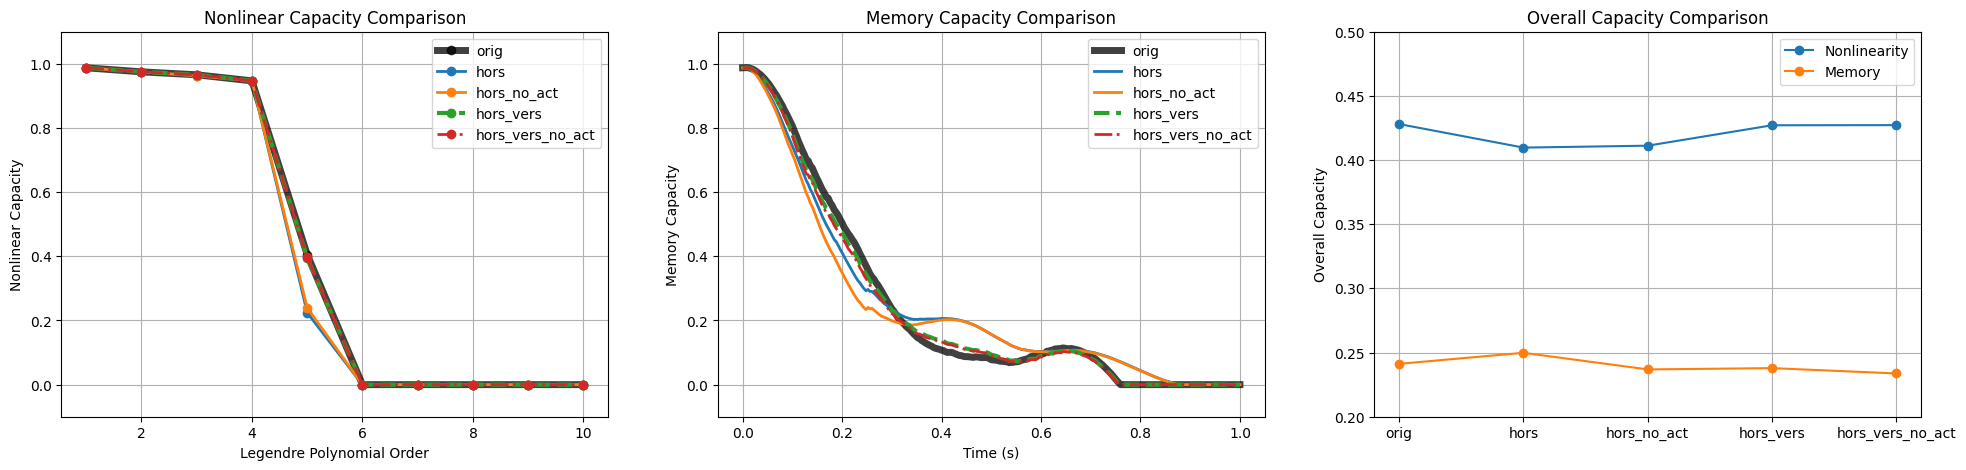

In [25]:
# No actuation point
plt.figure(figsize=(24, 5))
plt.subplot(131)
plt.plot(leg_x, data_dict['orig']['legendre_cap'], '-o', lw=5, color='k', label='orig', alpha=0.75)
plt.plot(leg_x, data_dict['hors']['legendre_cap'], '-o', lw=2, label='hors')
plt.plot(leg_x, data_dict['hors_no_act']['legendre_cap'], '-o', lw=2, label='hors_no_act')
plt.plot(leg_x, data_dict['hors_vers']['legendre_cap'], '--o', lw=3, label='hors_vers')
plt.plot(leg_x, data_dict['hors_vers_no_act']['legendre_cap'], '-.o', lw=2, label='hors_vers_no_act')
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear Capacity')
plt.title('Nonlinear Capacity Comparison')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_dict['orig']['memory_cap'], lw=5, color='k', label='orig', alpha=0.75)
plt.plot(mem_x, data_dict['hors']['memory_cap'], lw=2, label='hors')
plt.plot(mem_x, data_dict['hors_no_act']['memory_cap'], lw=2, label='hors_no_act')
plt.plot(mem_x, data_dict['hors_vers']['memory_cap'], '--', lw=3, label='hors_vers')
plt.plot(mem_x, data_dict['hors_vers_no_act']['memory_cap'], '-.', lw=2, label='hors_vers_no_act')
plt.xlabel('Time (s)')
plt.ylabel('Memory Capacity')
plt.title('Memory Capacity Comparison')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = ['orig', 'hors', 'hors_no_act', 'hors_vers', 'hors_vers_no_act']
onl_list = [sum(data_dict['orig']['legendre_cap'])/len(data_dict['orig']['legendre_cap']),
            sum(data_dict['hors']['legendre_cap'])/len(data_dict['hors']['legendre_cap']),
            sum(data_dict['hors_no_act']['legendre_cap'])/len(data_dict['hors_no_act']['legendre_cap']),
            sum(data_dict['hors_vers']['legendre_cap'])/len(data_dict['hors_vers']['legendre_cap']),
            sum(data_dict['hors_vers_no_act']['legendre_cap'])/len(data_dict['hors_vers_no_act']['legendre_cap'])]
oml_list = [sum(data_dict['orig']['memory_cap'])/len(data_dict['orig']['memory_cap']),
            sum(data_dict['hors']['memory_cap'])/len(data_dict['hors']['memory_cap']),
            sum(data_dict['hors_no_act']['memory_cap'])/len(data_dict['hors_no_act']['memory_cap']),
            sum(data_dict['hors_vers']['memory_cap'])/len(data_dict['hors_vers']['memory_cap']),
            sum(data_dict['hors_vers_no_act']['memory_cap'])/len(data_dict['hors_vers_no_act']['memory_cap'])]
plt.plot(labels_list, onl_list, '-o', label='Nonlinearity')
plt.plot(labels_list, oml_list, '-o', label='Memory')
plt.ylabel('Overall Capacity')
plt.title('Overall Capacity Comparison')
plt.ylim(0.2, 0.5)
plt.grid()
plt.legend()
plt.show()

## EVAL FUNCTIONS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import legendre
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import preprocessing

In [4]:
def nonlinearity_testing(input_data, output, leg_max_order, regressor, test_size, alpha):
    if regressor == "Lin":
        ### Linear Regression
        clf = LinearRegression()
    elif regressor == "Rid":
        ### Ridge Regression
        clf = Ridge(alpha=alpha)
    elif regressor == "Las":
        ### Lasso Regression
        clf = Lasso(alpha=alpha)
    elif regressor == "ElN":
        ### ElasticNet Regression
        clf = ElasticNet(alpha=alpha)
    else:
        print("Please specify the regressor")

    x = output
    capacity_train_list = []
    capacity_test_list = []
    R2_train_list = []
    R2_test_list = []
    Wout_list = []
    for n in range(1, leg_max_order+1):
        leg = legendre(n)
        y = leg(input_data)
        shape_input = input_data.shape
        train_size = int(shape_input[0] * (1 - test_size))
        y2 = (1/len(y)) * np.sum((y-np.mean(y))**2)

        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=True)
        
        # Training
        clf.fit(x_train, y_train)
        y_train_pred = clf.predict(x_train)

        idx = np.where(abs(y_train_pred) > 1)
        y_train_pred[idx] = np.mean(y)
        y_train[idx] = np.mean(y)

        # Testing
        y_test_pred = clf.predict(x_test)

        idx = np.where(abs(y_test_pred) > 1)
        y_test_pred[idx] = np.mean(y)
        y_test[idx] = np.mean(y)

        y2_train = (1/len(y_train)) * np.sum((y_train-np.mean(y_train))**2)

        MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
        capacity_train = 1 - MSE/y2_train
        R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

        y2_test = (1/len(y_test)) * np.sum((y_test-np.mean(y_test))**2)

        MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
        capacity_test = 1 - MSE/y2_test
        R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

        if R2_test < 0:
            R2_test = 0
        if R2_train < 0:
            R2_train = 0
        if capacity_test < 0:
            capacity_test = 0
        if capacity_train < 0:
            capacity_train = 0

        # print("legendre", n, "MSE", MSE_train, MSE_test, "y2", y2, "capacity", capacity_train, capacity_test)

        # plt.figure(figsize=(15, 5))
        # plt.subplot(121)
        # plt.scatter(input[:train_size, :], y_train, label='True')
        # plt.scatter(input[:train_size, :],y_train_pred, label='Predicted')
        # plt.title(f'Training Legendre {n}')
        # plt.legend()
        # plt.grid()

        # plt.subplot(122)
        # plt.scatter(input[train_size:, :], y_test, label='True')
        # plt.scatter(input[train_size:, :], y_test_pred, label='Predicted')
        # plt.title(f'Testing Legendre {n}')
        # plt.legend()
        # plt.grid()

        # plt.show()   

        if regressor == "Rid":
            Wout_list.append(clf.coef_)  

        capacity_train_list.append(capacity_train)
        capacity_test_list.append(capacity_test)
        R2_train_list.append(R2_train)
        R2_test_list.append(R2_test)

    np.savez(f"fiber_network/Simulations/SAGE/OutputReduction/Wout_list_nonlinearity_{regressor}.npz", Wout_list=Wout_list)

    return capacity_train_list, capacity_test_list, R2_train_list, R2_test_list

def memory_testing(input, output, max_timesteps_back, regressor, test_size, alpha):
    if regressor == "Lin":
        ### Linear Regression
        clf = LinearRegression()
    elif regressor == "Rid":
        ### Ridge Regression
        clf = Ridge(alpha=alpha)
    elif regressor == "Las":
        ### Lasso Regression
        clf = Lasso(alpha=alpha)
    elif regressor == "ElN":
        ### ElasticNet Regression
        clf = ElasticNet(alpha=alpha)
    else:
        print("Please specify the regressor")

    capacity_train_list = []
    capacity_test_list = []
    R2_train_list = []
    R2_test_list = []
    Wout_list = []
    for n in range(0, max_timesteps_back+1):
        x = output[n:]
        if n == 0:
            y = input
        else:
            y = input[:-n]

        y2 = (1/len(y)) * np.sum((y-np.mean(y))**2)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)
        
        # Training
        clf.fit(x_train, y_train)
        y_train_pred = clf.predict(x_train)

        idx = np.where(abs(y_train_pred) > 1)
        y_train_pred[idx] = np.mean(y)
        y_train[idx] = np.mean(y)

        # Testing
        y_test_pred = clf.predict(x_test)

        idx = np.where(abs(y_test_pred) > 1)
        y_test_pred[idx] = np.mean(y)
        y_test[idx] = np.mean(y)

        y2_train = (1/len(y_train)) * np.sum((y_train-np.mean(y_train))**2)

        MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
        capacity_train = 1 - MSE/y2_train
        R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

        y2_test = (1/len(y_test)) * np.sum((y_test-np.mean(y_test))**2)

        MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
        capacity_test = 1 - MSE/y2_test
        R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

        if R2_test < 0:
            R2_test = 0
        if R2_train < 0:
            R2_train = 0
        if capacity_test < 0:
            capacity_test = 0
        if capacity_train < 0:
            capacity_train = 0

        # plt.figure(figsize=(15, 5))
        # plt.subplot(121)
        # plt.scatter(y_train, y_train, label='True')
        # plt.plot(y_train_pred, label='Predicted')
        # plt.title(f'Training Memory {n}')
        # plt.legend()
        # plt.grid()

        # plt.subplot(122)
        # plt.plot(y_test, label='True')
        # plt.plot(y_test_pred, label='Predicted')
        # plt.title(f'Testing Memory {n}')
        # plt.legend()
        # plt.grid()

        # plt.show()

        if regressor == "Rid":
            Wout_list.append(clf.coef_) 

        capacity_train_list.append(capacity_train)
        capacity_test_list.append(capacity_test)
        R2_train_list.append(R2_train)
        R2_test_list.append(R2_test)

        # print("memory", n, R2_train, R2_test, capacity_train, capacity_test)
    
    np.savez(f"fiber_network/Simulations/SAGE/OutputReduction/Wout_list_memory_{regressor}.npz", Wout_list=Wout_list)

    return capacity_train_list, capacity_test_list, R2_train_list, R2_test_list

def memory_testing_less(input, output, max_timesteps_back, regressor, test_size, alpha):
    if regressor == "Lin":
        ### Linear Regression
        clf = LinearRegression()
    elif regressor == "Rid":
        ### Ridge Regression
        clf = Ridge(alpha=alpha)
    elif regressor == "Las":
        ### Lasso Regression
        clf = Lasso(alpha=alpha)
    elif regressor == "ElN":
        ### ElasticNet Regression
        clf = ElasticNet(alpha=alpha)
    else:
        print("Please specify the regressor")

    capacity_train_list = []
    capacity_test_list = []
    R2_train_list = []
    R2_test_list = []
    Wout_list = []
    for n in max_timesteps_back:
        x = output[n:]
        if n == 0:
            y = input
        else:
            y = input[:-n]

        y2 = (1/len(y)) * np.sum((y-np.mean(y))**2)
        x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=42, shuffle=False)
        
        # Training
        clf.fit(x_train, y_train)
        y_train_pred = clf.predict(x_train)

        idx = np.where(abs(y_train_pred) > 1)
        y_train_pred[idx] = np.mean(y)
        y_train[idx] = np.mean(y)

        # Testing
        y_test_pred = clf.predict(x_test)

        idx = np.where(abs(y_test_pred) > 1)
        y_test_pred[idx] = np.mean(y)
        y_test[idx] = np.mean(y)

        y2_train = (1/len(y_train)) * np.sum((y_train-np.mean(y_train))**2)

        MSE = mean_squared_error(y_true=y_train, y_pred=y_train_pred)
        capacity_train = 1 - MSE/y2_train
        R2_train = r2_score(y_true=y_train, y_pred=y_train_pred)

        y2_test = (1/len(y_test)) * np.sum((y_test-np.mean(y_test))**2)

        MSE = mean_squared_error(y_true=y_test, y_pred=y_test_pred)
        capacity_test = 1 - MSE/y2_test
        R2_test = r2_score(y_true=y_test, y_pred=y_test_pred)

        if R2_test < 0:
            R2_test = 0
        if R2_train < 0:
            R2_train = 0
        if capacity_test < 0:
            capacity_test = 0
        if capacity_train < 0:
            capacity_train = 0

        # plt.figure(figsize=(15, 5))
        # plt.subplot(121)
        # plt.scatter(y_train, y_train, label='True')
        # plt.plot(y_train_pred, label='Predicted')
        # plt.title(f'Training Memory {n}')
        # plt.legend()
        # plt.grid()

        # plt.subplot(122)
        # plt.plot(y_test, label='True')
        # plt.plot(y_test_pred, label='Predicted')
        # plt.title(f'Testing Memory {n}')
        # plt.legend()
        # plt.grid()

        # plt.show()

        if regressor == "Rid":
            Wout_list.append(clf.coef_) 

        capacity_train_list.append(capacity_train)
        capacity_test_list.append(capacity_test)
        R2_train_list.append(R2_train)
        R2_test_list.append(R2_test)

        # print("memory", n, R2_train, R2_test, capacity_train, capacity_test)
    
    # if regressor == "Rid":
    #     np.savez("./Wout_list_memory.npz", Wout_list=Wout_list)

    return capacity_train_list, capacity_test_list, R2_train_list, R2_test_list

In [ ]:
orig = np.load("6by6_orig.npz", allow_pickle=True)

leg = 'legendre_R2'
mem = 'memory_R2'

regressor = 'Rid'
test_size = 0.25
alpha_list = [1e-3, 1e-2, 1e-1, 1e-0, 1e1, 1e2]

leg_max_order = 10
max_time_back_seconds = 1
max_timesteps_back = np.rint(250*max_time_back_seconds).astype(int)
leg_x = np.linspace(1, leg_max_order, leg_max_order)
mem_x = np.linspace(0, max_time_back_seconds, max_timesteps_back+1)

data = orig
ip = data['input_data']
ip = -1 + (ip - np.min(ip)) / (np.max(ip) - np.min(ip)) * (1 - (-1))

op = data['output_data']
op /= np.mean(op, axis=0)
op /= np.std(op, axis=0)
scaler = preprocessing.StandardScaler().fit(op)
op = scaler.transform(op)

delta_leg_list = []
delta_mem_list = []

for alpha in alpha_list:
    # Nonlinearity testing
    leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(ip, op, leg_max_order, regressor, test_size, alpha)

    delta_leg = sum(leg_R2_train_list)/len(leg_R2_train_list) - sum(leg_R2_test_list)/len(leg_R2_test_list)

    # Memory testing
    mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(ip, op, max_timesteps_back, regressor, test_size, alpha)

    delta_mem = sum(mem_R2_train_list)/len(mem_R2_train_list) - sum(mem_R2_test_list)/len(mem_R2_test_list)

    print(f"Alpha = {alpha} - Nonlinearity Training; {sum(leg_R2_train_list)/len(leg_R2_train_list)}, Testing: {sum(leg_R2_test_list)/len(leg_R2_test_list)}")
    print(f"Alpha = {alpha} - Memory Training; {sum(mem_R2_train_list)/len(mem_R2_train_list)}, Testing: {sum(mem_R2_test_list)/len(mem_R2_test_list)}")

    delta_leg_list.append(delta_leg)
    delta_mem_list.append(delta_mem)

Alpha = 0.001 - Nonlinearity Training; 0.9331371766422898, Testing: 0.9383444762060174
Alpha = 0.001 - Memory Training; 0.556081938345753, Testing: 0.4671995624091401
Alpha = 0.01 - Nonlinearity Training; 0.9118953115433761, Testing: 0.9160816833718004
Alpha = 0.01 - Memory Training; 0.5050006740867433, Testing: 0.4231044883307152
Alpha = 0.1 - Nonlinearity Training; 0.8929003784344468, Testing: 0.8979827896686873
Alpha = 0.1 - Memory Training; 0.41008140872503973, Testing: 0.3398844657566094
Alpha = 1.0 - Nonlinearity Training; 0.8569444903498242, Testing: 0.8651729141946551
Alpha = 1.0 - Memory Training; 0.251086082199058, Testing: 0.1974632516921412
Alpha = 10.0 - Nonlinearity Training; 0.8169703474525077, Testing: 0.8229625316937195
Alpha = 10.0 - Memory Training; 0.1553336109414305, Testing: 0.1163252911469911
Alpha = 100.0 - Nonlinearity Training; 0.7507582795708914, Testing: 0.7562000277062476
Alpha = 100.0 - Memory Training; 0.12409418917762834, Testing: 0.0984851472775954


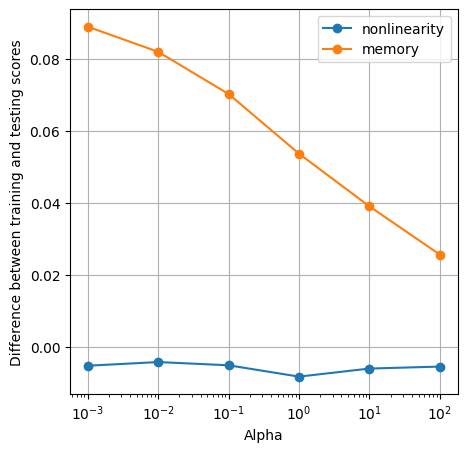

In [4]:
plt.figure(figsize=(5, 5))
plt.plot(alpha_list, delta_leg_list, '-o', label='nonlinearity')
plt.plot(alpha_list, delta_mem_list, '-o', label='memory')
plt.semilogx()
plt.xlabel('Alpha')
plt.ylabel('Difference between training and testing scores')
plt.legend()
plt.grid()
plt.show()

In [5]:
orig = np.load("6by6_orig.npz", allow_pickle=True)

leg = 'legendre_R2'
mem = 'memory_R2'

regressor_list = ['Lin', 'Rid', 'Las', 'ElN']
test_size = 0.25
alpha = 1e-2

leg_max_order = 10
max_time_back_seconds = 1
max_timesteps_back = np.rint(250*max_time_back_seconds).astype(int)
leg_x = np.linspace(1, leg_max_order, leg_max_order)
mem_x = np.linspace(0, max_time_back_seconds, max_timesteps_back+1)

data = orig
ip = data['input_data']
ip = -1 + (ip - np.min(ip)) / (np.max(ip) - np.min(ip)) * (1 - (-1))

op = data['output_data']
op /= np.mean(op, axis=0)
op /= np.std(op, axis=0)
scaler = preprocessing.StandardScaler().fit(op)
op = scaler.transform(op)

leg_list = []
mem_list = []

for regressor in regressor_list:
    # Nonlinearity testing
    leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(ip, op, leg_max_order, regressor, test_size, alpha)

    # Memory testing
    mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(ip, op, max_timesteps_back, regressor, test_size, alpha)

    print(f"Regressor = {regressor} - Nonlinearity Training; {sum(leg_R2_train_list)/len(leg_R2_train_list)}, Testing: {sum(leg_R2_test_list)/len(leg_R2_test_list)}")
    print(f"Regressor = {regressor} - Memory Training; {sum(mem_R2_train_list)/len(mem_R2_train_list)}, Testing: {sum(mem_R2_test_list)/len(mem_R2_test_list)}")

    leg_list.append(leg_R2_train_list)
    mem_list.append(mem_R2_train_list)

FileNotFoundError: [Errno 2] No such file or directory: 'fiber_network/Simulations/SAGE/OutputReduction/Wout_list_nonlinearity_Lin.npz'

In [ ]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
for i in range(len(regressor_list)):
    plt.plot(leg_x, leg_list[i], '-o', label=regressor_list[i])
plt.xlabel('Legendre Polynomial order')
plt.ylabel('Nonlinearity R2 score')
plt.legend()
plt.grid()
plt.subplot(122)
for i in range(len(regressor_list)):
    plt.plot(mem_x, mem_list[i], '-o', label=regressor_list[i])
plt.xlabel('Time (s)')
plt.ylabel('Memory R2 score')
plt.legend()
plt.grid()
plt.show()

### 6 GROUPS of OUTPUTS

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Load the data
folder = "SixGroups_6x6_100s"
orig = np.load(f"{folder}/6by6_orig.npz", allow_pickle=True)
name_list_1 = ['orig', 'conns_x', 'conns_y', 'hors_x', 'hors_y', 'vers_x', 'vers_y']

name_list_2 = ['orig', 'conns_xy', 'conns_x_hors_x', 'conns_x_hors_y', 'conns_x_vers_x', 'conns_x_vers_y', 'conns_y_hors_x', 'conns_y_hors_y', 'conns_y_vers_x', 'conns_y_vers_y', 
                'hors_xy', 'hors_x_vers_x', 'hors_x_vers_y', 'hors_y_vers_x', 'hors_y_vers_y', 'vers_xy']

name_list_3 = ['orig', 'conns_xy_hors_x', 'conns_xy_hors_y', 'conns_xy_vers_x', 'conns_xy_vers_y', 'conns_x_hors_xy', 'conns_x_hors_x_vers_x', 'conns_x_hors_x_vers_y', 'conns_x_hors_y_vers_x', 
                'conns_x_hors_y_vers_y', 'conns_x_vers_xy', 'conns_y_hors_xy', 'conns_y_hors_x_vers_x', 'conns_y_hors_x_vers_y', 'conns_y_hors_y_vers_x', 'conns_y_hors_y_vers_y', 'conns_y_vers_xy',
                'hors_xy_vers_x', 'hors_xy_vers_y', 'hors_x_vers_xy', 'hors_y_vers_xy']

name_list_4 = ['orig', 'conns_xy_hors_xy', 'conns_xy_hors_x_vers_x', 'conns_xy_hors_x_vers_y', 'conns_xy_hors_y_vers_x', 'conns_xy_hors_y_vers_y', 'conns_xy_vers_xy',
                'conns_x_hors_xy_vers_x', 'conns_x_hors_xy_vers_y', 'conns_x_hors_x_vers_xy', 'conns_x_hors_y_vers_xy', 'conns_y_hors_xy_vers_x', 'conns_y_hors_xy_vers_y', 
                'conns_y_hors_x_vers_xy', 'conns_y_hors_y_vers_xy', 'hors_xy_vers_xy']

name_list_5 = ['orig', 'conns_xy_hors_xy_vers_x', 'conns_xy_hors_xy_vers_y', 'conns_xy_hors_x_vers_xy', 'conns_xy_hors_y_vers_xy', 'conns_x_hors_xy_vers_xy',
                'conns_y_hors_xy_vers_xy']

leg = 'legendre_R2'
mem = 'memory_R2'

regressor = 'Rid'
test_size = 0.25
alpha = 1e-3
reeval = True

leg_max_order = 10
max_time_back_seconds = 1
max_timesteps_back = np.rint(250*max_time_back_seconds).astype(int)
leg_x = np.linspace(1, leg_max_order, leg_max_order)
mem_x = np.linspace(0, max_time_back_seconds, max_timesteps_back+1)

data = orig
ip = data['input_data']
ip = -1 + (ip - np.min(ip)) / (np.max(ip) - np.min(ip)) * (1 - (-1))

op = data['output_data']
op /= np.mean(op, axis=0)
op /= np.std(op, axis=0)
scaler = preprocessing.StandardScaler().fit(op)
op = scaler.transform(op)

# Nonlinearity testing
leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(ip, op, leg_max_order, regressor, test_size, alpha)

# Memory testing
mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(ip, op, max_timesteps_back, regressor, test_size, alpha)

data[leg][0] = leg_R2_train_list
data[leg][1] = leg_R2_test_list
data['legendre_cap'][0] = leg_capacity_train_list
data['legendre_cap'][1] = leg_capacity_test_list

data[mem][0] = mem_R2_train_list
data[mem][1] = mem_R2_test_list
data['memory_cap'][0] = mem_capacity_train_list
data['memory_cap'][1] = mem_capacity_test_list

data_list_1 = [orig]
for name in name_list_1[1:]:
    data = np.load(f"{folder}/6by6_ops_{name}.npz", allow_pickle=True)

    if reeval:
        ip = data['input_data']
        ip = -1 + (ip - np.min(ip)) / (np.max(ip) - np.min(ip)) * (1 - (-1))

        op = data['output_data']
        op /= np.mean(op, axis=0)
        op /= np.std(op, axis=0)
        scaler = preprocessing.StandardScaler().fit(op)
        op = scaler.transform(op)

        # Nonlinearity testing
        leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(ip, op, leg_max_order, regressor, test_size, alpha)

        # Memory testing
        mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(ip, op, max_timesteps_back, regressor, test_size, alpha)

        data[leg][0] = leg_R2_train_list
        data[leg][1] = leg_R2_test_list
        data['legendre_cap'][0] = leg_capacity_train_list
        data['legendre_cap'][1] = leg_capacity_test_list

        data[mem][0] = mem_R2_train_list
        data[mem][1] = mem_R2_test_list
        data['memory_cap'][0] = mem_capacity_train_list
        data['memory_cap'][1] = mem_capacity_test_list

    data_list_1.append(data)   
    
data_list_2 = [orig]
for name in name_list_2[1:]:
    data = np.load(f"{folder}/6by6_ops_{name}.npz", allow_pickle=True)

    if reeval:
        ip = data['input_data']
        ip = -1 + (ip - np.min(ip)) / (np.max(ip) - np.min(ip)) * (1 - (-1))

        op = data['output_data']
        op /= np.mean(op, axis=0)
        op /= np.std(op, axis=0)
        scaler = preprocessing.StandardScaler().fit(op)
        op = scaler.transform(op)

        # Nonlinearity testing
        leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(ip, op, leg_max_order, regressor, test_size, alpha)

        # Memory testing
        mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(ip, op, max_timesteps_back, regressor, test_size, alpha)

        data[leg][0] = leg_R2_train_list
        data[leg][1] = leg_R2_test_list
        data['legendre_cap'][0] = leg_capacity_train_list
        data['legendre_cap'][1] = leg_capacity_test_list

        data[mem][0] = mem_R2_train_list
        data[mem][1] = mem_R2_test_list
        data['memory_cap'][0] = mem_capacity_train_list
        data['memory_cap'][1] = mem_capacity_test_list

    data_list_2.append(data)

data_list_3 = [orig]
for name in name_list_3[1:]:
    data = np.load(f"{folder}/6by6_ops_{name}.npz", allow_pickle=True)

    if reeval:
        ip = data['input_data']
        ip = -1 + (ip - np.min(ip)) / (np.max(ip) - np.min(ip)) * (1 - (-1))

        op = data['output_data']
        op /= np.mean(op, axis=0)
        op /= np.std(op, axis=0)
        scaler = preprocessing.StandardScaler().fit(op)
        op = scaler.transform(op)

        # Nonlinearity testing
        leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(ip, op, leg_max_order, regressor, test_size, alpha)

        # Memory testing
        mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(ip, op, max_timesteps_back, regressor, test_size, alpha)

        data[leg][0] = leg_R2_train_list
        data[leg][1] = leg_R2_test_list
        data['legendre_cap'][0] = leg_capacity_train_list
        data['legendre_cap'][1] = leg_capacity_test_list

        data[mem][0] = mem_R2_train_list
        data[mem][1] = mem_R2_test_list
        data['memory_cap'][0] = mem_capacity_train_list
        data['memory_cap'][1] = mem_capacity_test_list

    data_list_3.append(data)

data_list_4 = [orig]
for name in name_list_4[1:]:
    data = np.load(f"{folder}/6by6_ops_{name}.npz", allow_pickle=True)

    if reeval:
        ip = data['input_data']
        ip = -1 + (ip - np.min(ip)) / (np.max(ip) - np.min(ip)) * (1 - (-1))

        op = data['output_data']
        op /= np.mean(op, axis=0)
        op /= np.std(op, axis=0)
        scaler = preprocessing.StandardScaler().fit(op)
        op = scaler.transform(op)

        # Nonlinearity testing
        leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(ip, op, leg_max_order, regressor, test_size, alpha)

        # Memory testing
        mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(ip, op, max_timesteps_back, regressor, test_size, alpha)

        data[leg][0] = leg_R2_train_list
        data[leg][1] = leg_R2_test_list
        data['legendre_cap'][0] = leg_capacity_train_list
        data['legendre_cap'][1] = leg_capacity_test_list

        data[mem][0] = mem_R2_train_list
        data[mem][1] = mem_R2_test_list
        data['memory_cap'][0] = mem_capacity_train_list
        data['memory_cap'][1] = mem_capacity_test_list

    data_list_4.append(data)

data_list_5 = [orig]
for name in name_list_5[1:]:
    data = np.load(f"{folder}/6by6_ops_{name}.npz", allow_pickle=True)

    if reeval:
        ip = data['input_data']
        ip = -1 + (ip - np.min(ip)) / (np.max(ip) - np.min(ip)) * (1 - (-1))

        op = data['output_data']
        op /= np.mean(op, axis=0)
        op /= np.std(op, axis=0)
        scaler = preprocessing.StandardScaler().fit(op)
        op = scaler.transform(op)

        # Nonlinearity testing
        leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(ip, op, leg_max_order, regressor, test_size, alpha)

        # Memory testing
        mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(ip, op, max_timesteps_back, regressor, test_size, alpha)

        data[leg][0] = leg_R2_train_list
        data[leg][1] = leg_R2_test_list
        data['legendre_cap'][0] = leg_capacity_train_list
        data['legendre_cap'][1] = leg_capacity_test_list

        data[mem][0] = mem_R2_train_list
        data[mem][1] = mem_R2_test_list
        data['memory_cap'][0] = mem_capacity_train_list
        data['memory_cap'][1] = mem_capacity_test_list

    data_list_5.append(data)

# # Extract data for plotting
# data_dict = {}
# for data, name in zip(data_list, name_list):
#     leg_cap_test = data['legendre_cap'][1]
#     mem_cap_test = data['memory_cap'][1]
#     data_dict[name] = {'legendre_cap': leg_cap_test, 'memory_cap': mem_cap_test}

print(sum(data[leg][0])/len(data[leg][0]), sum(data[leg][1])/len(data[leg][1]))
print(sum(data[mem][0])/len(data[mem][0]), sum(data[mem][1])/len(data[mem][1]))

0.6489778915063347 0.6211647084342626
0.5341644967615887 0.4397740437538997


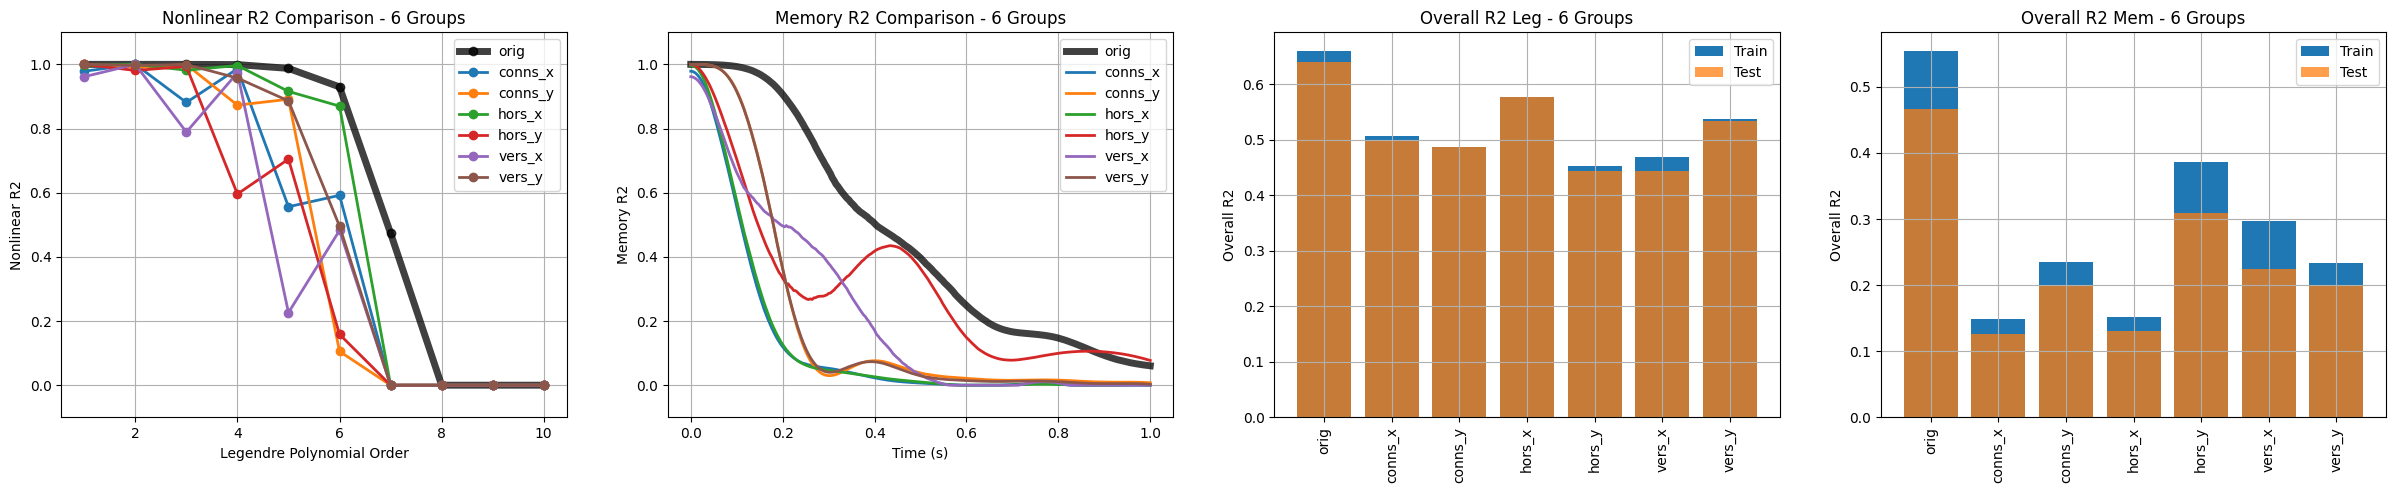

In [8]:
plt.figure(figsize=(30, 5))
plt.subplot(141)
plt.plot(leg_x, data_list_1[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_1[1:], name_list_1[1:]):
    plt.plot(leg_x, data[leg][1], '-o', lw=2, label=name)

plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinear R2 Comparison - 6 Groups')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(142)
plt.plot(mem_x, data_list_1[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_1[1:], name_list_1[1:]):
    plt.plot(mem_x, data[mem][1], lw=2, label=name)
    
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory R2 Comparison - 6 Groups')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()

labels_list = name_list_1
plt.subplot(143)
onl_list_11 = [sum(data[leg][0])/len(data[leg][0]) for data in data_list_1]
onl_list_12 = [sum(data[leg][1])/len(data[leg][1]) for data in data_list_1]

plt.bar(labels_list, onl_list_11, label='Train')
plt.bar(labels_list, onl_list_12, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Leg - 6 Groups')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.subplot(144)
oml_list_11 = [sum(data[mem][0])/len(data[mem][0]) for data in data_list_1]
oml_list_12 = [sum(data[mem][1])/len(data[mem][1]) for data in data_list_1]

plt.bar(labels_list, oml_list_11, label='Train')
plt.bar(labels_list, oml_list_12, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Mem - 6 Groups')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.show()

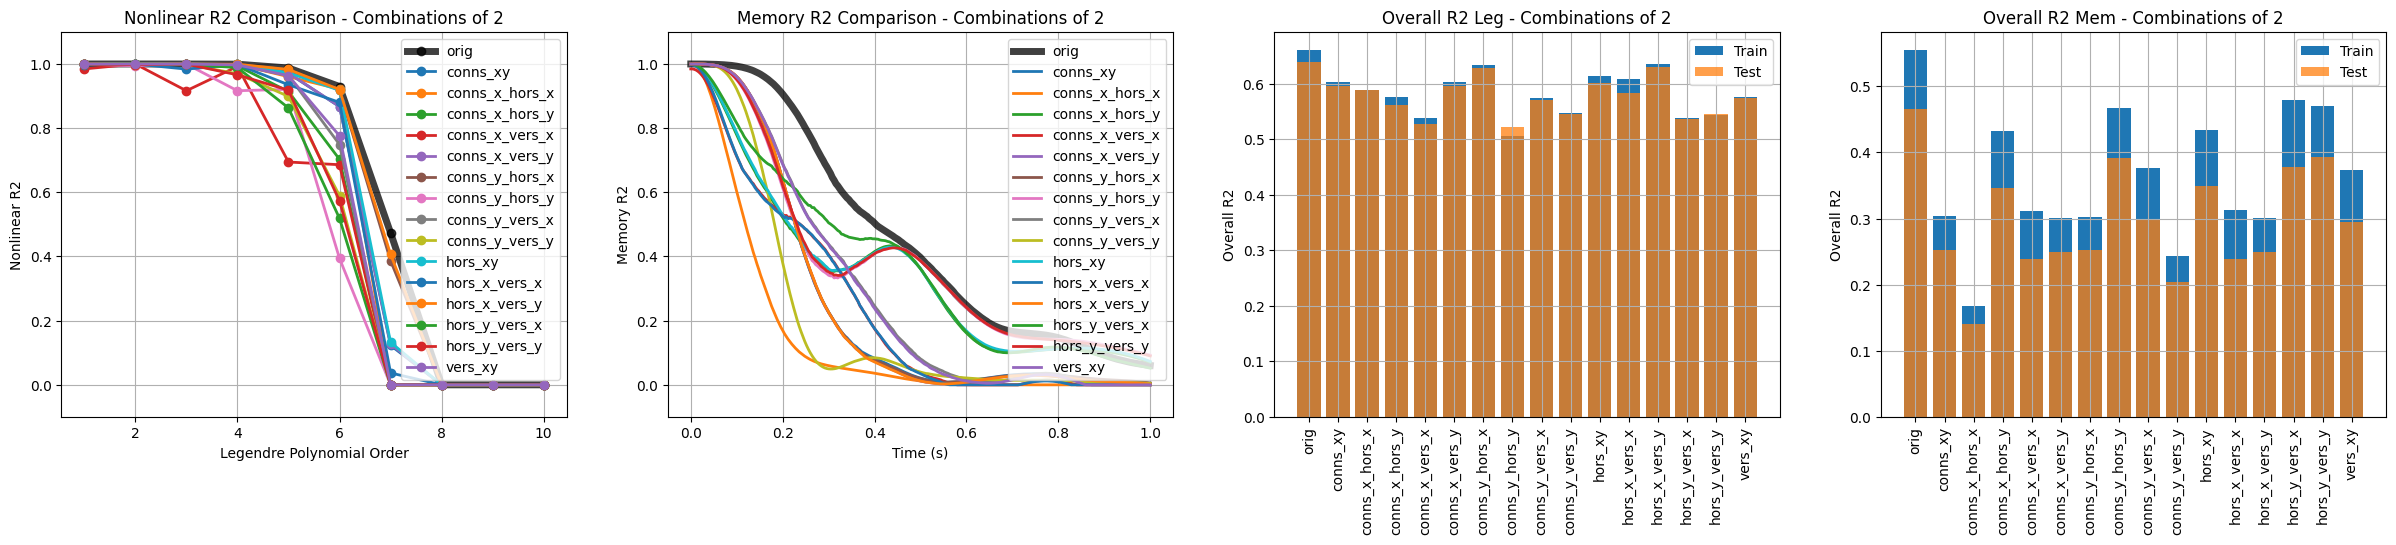

In [9]:
plt.figure(figsize=(30, 5))
plt.subplot(141)
plt.plot(leg_x, data_list_2[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_2[1:], name_list_2[1:]):
    plt.plot(leg_x, data[leg][1], '-o', lw=2, label=name)

plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinear R2 Comparison - Combinations of 2')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(142)
plt.plot(mem_x, data_list_2[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_2[1:], name_list_2[1:]):
    plt.plot(mem_x, data[mem][1], lw=2, label=name)
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory R2 Comparison - Combinations of 2')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()

labels_list = name_list_2
plt.subplot(143)
onl_list_21 = [sum(data[leg][0])/len(data[leg][0]) for data in data_list_2]
onl_list_22 = [sum(data[leg][1])/len(data[leg][1]) for data in data_list_2]

plt.bar(labels_list, onl_list_21, label='Train')
plt.bar(labels_list, onl_list_22, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Leg - Combinations of 2')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.subplot(144)
oml_list_21 = [sum(data[mem][0])/len(data[mem][0]) for data in data_list_2]
oml_list_22 = [sum(data[mem][1])/len(data[mem][1]) for data in data_list_2]

plt.bar(labels_list, oml_list_21, label='Train')
plt.bar(labels_list, oml_list_22, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Mem - Combinations of 2')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.show()

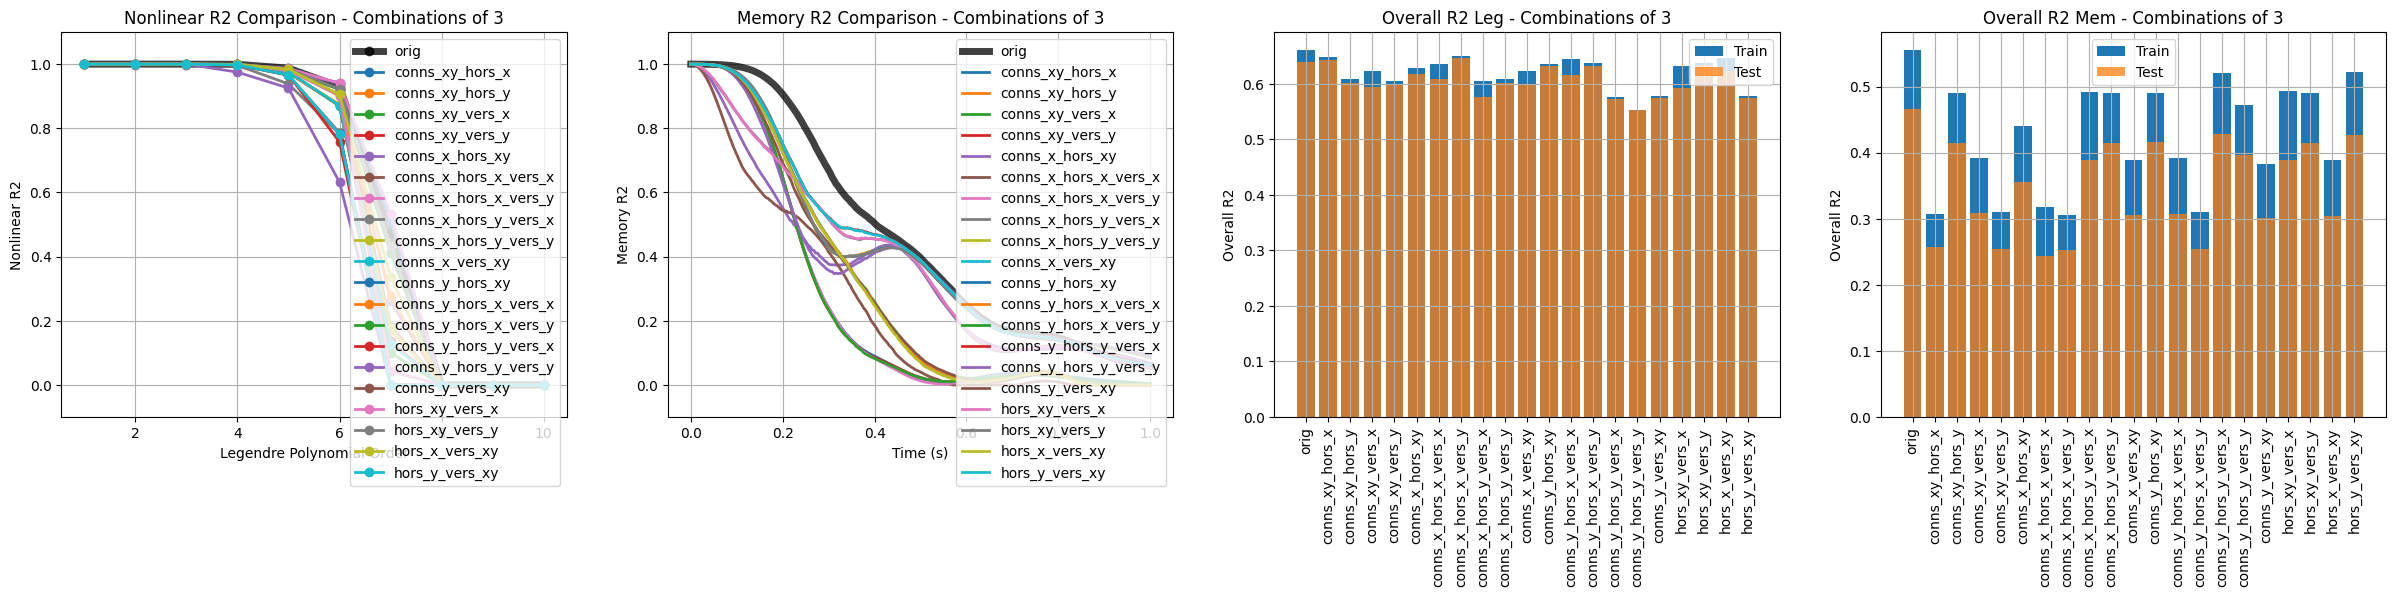

In [10]:
plt.figure(figsize=(30, 5))
plt.subplot(141)
plt.plot(leg_x, data_list_3[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_3[1:], name_list_3[1:]):
    plt.plot(leg_x, data[leg][1], '-o', lw=2, label=name)

plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinear R2 Comparison - Combinations of 3')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(142)
plt.plot(mem_x, data_list_3[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_3[1:], name_list_3[1:]):
    plt.plot(mem_x, data[mem][1], lw=2, label=name)
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory R2 Comparison - Combinations of 3')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()

labels_list = name_list_3
plt.subplot(143)
onl_list_31 = [sum(data[leg][0])/len(data[leg][0]) for data in data_list_3]
onl_list_32 = [sum(data[leg][1])/len(data[leg][1]) for data in data_list_3]

plt.bar(labels_list, onl_list_31, label='Train')
plt.bar(labels_list, onl_list_32, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Leg - Combinations of 3')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.subplot(144)
oml_list_31 = [sum(data[mem][0])/len(data[mem][0]) for data in data_list_3]
oml_list_32 = [sum(data[mem][1])/len(data[mem][1]) for data in data_list_3]

plt.bar(labels_list, oml_list_31, label='Train')
plt.bar(labels_list, oml_list_32, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Mem - Combinations of 3')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.show()

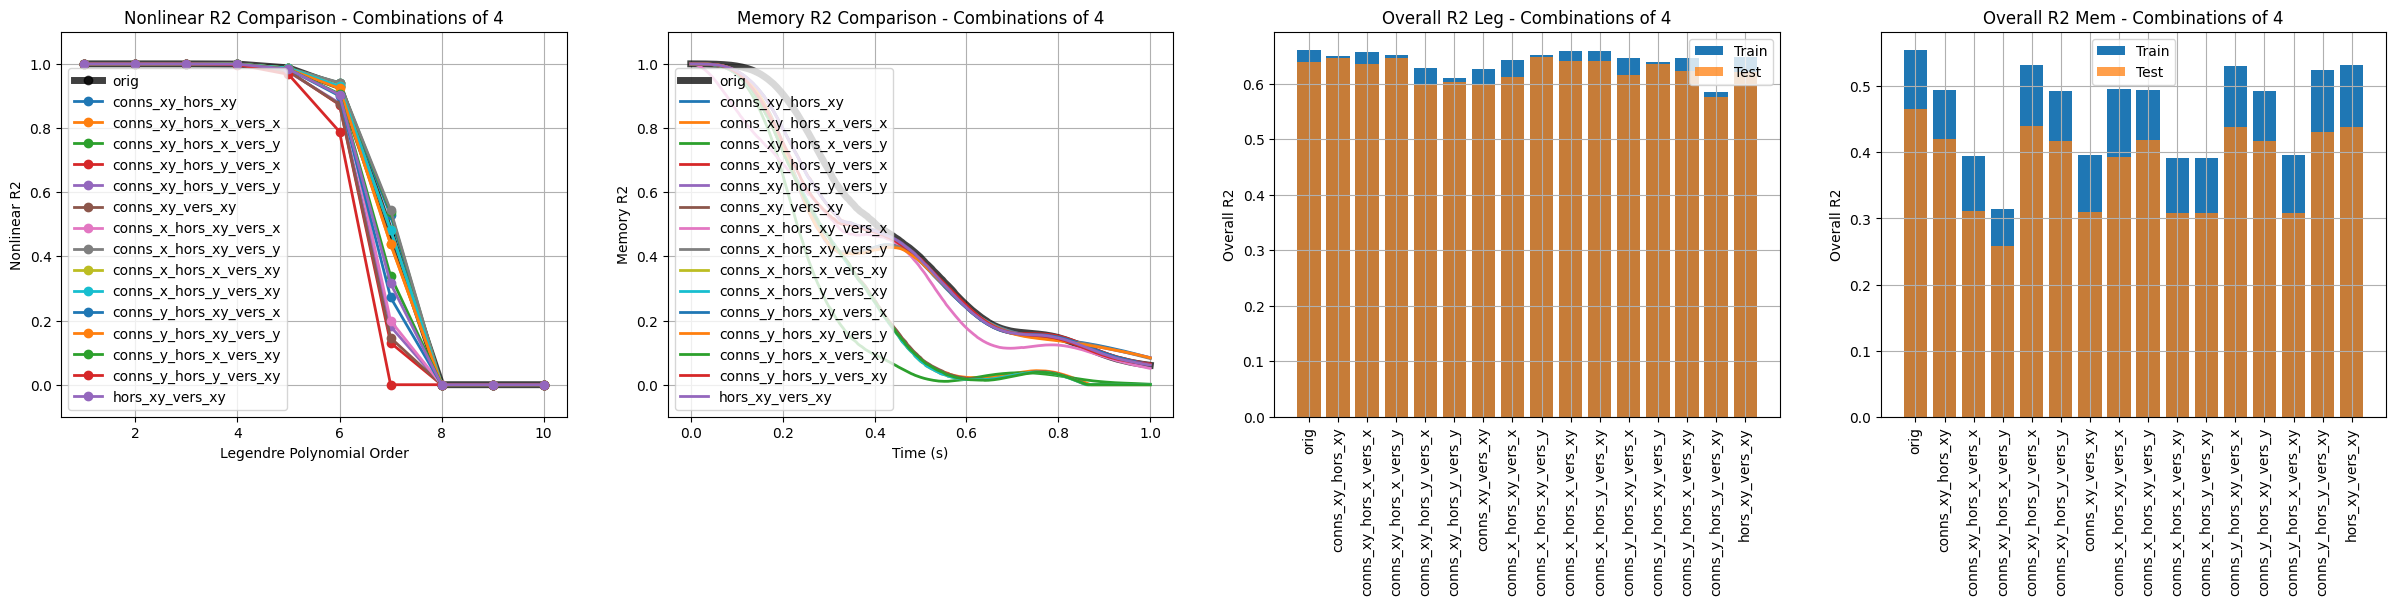

In [11]:
plt.figure(figsize=(30, 5))
plt.subplot(141)
plt.plot(leg_x, data_list_4[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_4[1:], name_list_4[1:]):
    plt.plot(leg_x, data[leg][1], '-o', lw=2, label=name)

plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinear R2 Comparison - Combinations of 4')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(142)
plt.plot(mem_x, data_list_4[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_4[1:], name_list_4[1:]):
    plt.plot(mem_x, data[mem][1], lw=2, label=name)
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory R2 Comparison - Combinations of 4')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()

labels_list = name_list_4
plt.subplot(143)
onl_list_41 = [sum(data[leg][0])/len(data[leg][0]) for data in data_list_4]
onl_list_42 = [sum(data[leg][1])/len(data[leg][1]) for data in data_list_4]

plt.bar(labels_list, onl_list_41, label='Train')
plt.bar(labels_list, onl_list_42, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Leg - Combinations of 4')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.subplot(144)
oml_list_41 = [sum(data[mem][0])/len(data[mem][0]) for data in data_list_4]
oml_list_42 = [sum(data[mem][1])/len(data[mem][1]) for data in data_list_4]

plt.bar(labels_list, oml_list_41, label='Train')
plt.bar(labels_list, oml_list_42, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Mem - Combinations of 4')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.show()

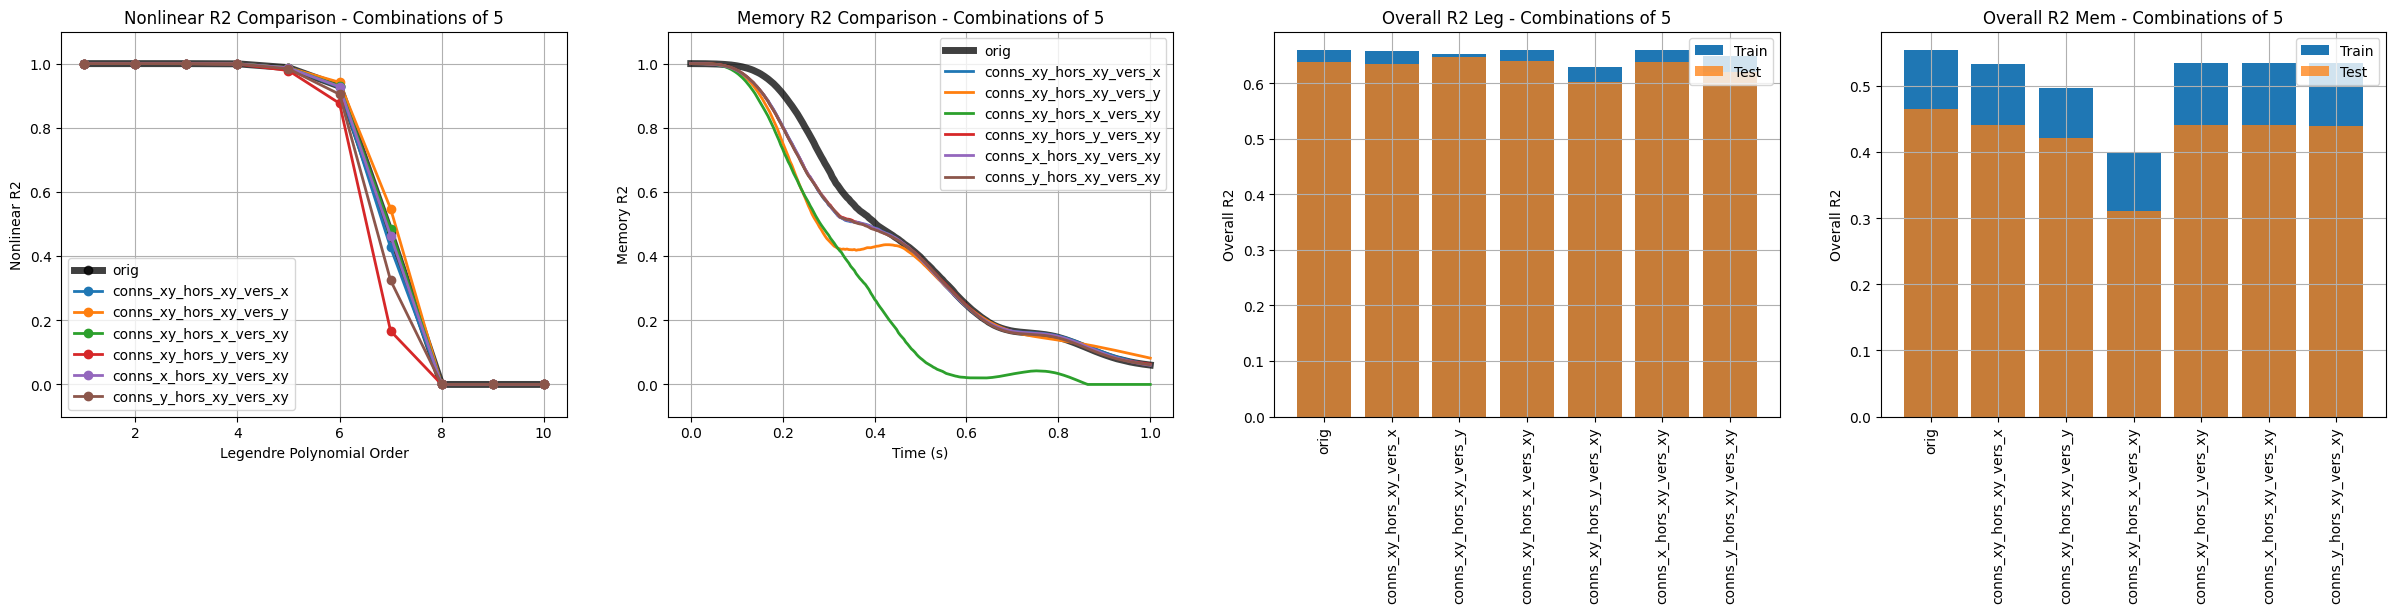

In [12]:
plt.figure(figsize=(30, 5))
plt.subplot(141)
plt.plot(leg_x, data_list_5[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_5[1:], name_list_5[1:]):
    plt.plot(leg_x, data[leg][1], '-o', lw=2, label=name)

plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinear R2 Comparison - Combinations of 5')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(142)
plt.plot(mem_x, data_list_5[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
for data, name in zip(data_list_5[1:], name_list_5[1:]):
    plt.plot(mem_x, data[mem][1], lw=2, label=name)
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory R2 Comparison - Combinations of 5')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()

labels_list = name_list_5
plt.subplot(143)
onl_list_51 = [sum(data[leg][0])/len(data[leg][0]) for data in data_list_5]
onl_list_52 = [sum(data[leg][1])/len(data[leg][1]) for data in data_list_5]

plt.bar(labels_list, onl_list_51, label='Train')
plt.bar(labels_list, onl_list_52, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Leg - Combinations of 5')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.subplot(144)
oml_list_51 = [sum(data[mem][0])/len(data[mem][0]) for data in data_list_5]
oml_list_52 = [sum(data[mem][1])/len(data[mem][1]) for data in data_list_5]

plt.bar(labels_list, oml_list_51, label='Train')
plt.bar(labels_list, oml_list_52, label='Test', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Mem - Combinations of 5')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.show()

In [13]:
## Getting highest of each category
max_leg_train_dict = {'orig': (onl_list_11[0], oml_list_11[0])}
max_leg_test_dict = {'orig': (onl_list_12[0], oml_list_12[0])}
max_mem_train_dict = {'orig': (onl_list_11[0], oml_list_11[0])}
max_mem_test_dict = {'orig': (onl_list_12[0], oml_list_12[0])}


idx_leg_11 = onl_list_11[1:].index(max(onl_list_11[1:])) + 1
name = name_list_1[idx_leg_11]
max_leg_train_dict[name] = (onl_list_11[idx_leg_11], oml_list_11[idx_leg_11])
idx_leg_12 = onl_list_12[1:].index(max(onl_list_12[1:])) + 1
name = name_list_1[idx_leg_12]
max_leg_test_dict[name] = (onl_list_12[idx_leg_12], oml_list_12[idx_leg_12])

idx_mem_11 = oml_list_11[1:].index(max(oml_list_11[1:])) + 1
name = name_list_1[idx_mem_11]
max_mem_train_dict[name] = (onl_list_11[idx_mem_11], oml_list_11[idx_mem_11])
idx_mem_12 = oml_list_12[1:].index(max(oml_list_12[1:])) + 1
name = name_list_1[idx_mem_12]
max_mem_test_dict[name] = (onl_list_12[idx_mem_12], oml_list_12[idx_mem_12])

idx_leg_21 = onl_list_21[1:].index(max(onl_list_21[1:])) + 1
name = name_list_2[idx_leg_21]
max_leg_train_dict[name] = (onl_list_21[idx_leg_21], oml_list_21[idx_leg_21])
idx_leg_22 = onl_list_22[1:].index(max(onl_list_22[1:])) + 1
name = name_list_2[idx_leg_22]
max_leg_test_dict[name] = (onl_list_22[idx_leg_22], oml_list_22[idx_leg_22])

idx_mem_21 = oml_list_21[1:].index(max(oml_list_21[1:])) + 1
name = name_list_2[idx_mem_21]
max_mem_train_dict[name] = (onl_list_21[idx_mem_21], oml_list_21[idx_mem_21])
idx_mem_22 = oml_list_22[1:].index(max(oml_list_22[1:])) + 1
name = name_list_2[idx_mem_22]
max_mem_test_dict[name] = (onl_list_22[idx_mem_22], oml_list_22[idx_mem_22])

idx_leg_31 = onl_list_31[1:].index(max(onl_list_31[1:])) + 1
name = name_list_3[idx_leg_31]
max_leg_train_dict[name] = (onl_list_31[idx_leg_31], oml_list_31[idx_leg_31])
idx_leg_32 = onl_list_32[1:].index(max(onl_list_32[1:])) + 1
name = name_list_3[idx_leg_32]
max_leg_test_dict[name] = (onl_list_32[idx_leg_32], oml_list_32[idx_leg_32])

idx_mem_31 = oml_list_31[1:].index(max(oml_list_31[1:])) + 1
name = name_list_3[idx_mem_31]
max_mem_train_dict[name] = (onl_list_31[idx_mem_31], oml_list_31[idx_mem_31])
idx_mem_32 = oml_list_32[1:].index(max(oml_list_32[1:])) + 1
name = name_list_3[idx_mem_32]
max_mem_test_dict[name] = (onl_list_32[idx_mem_32], oml_list_32[idx_mem_32])

idx_leg_41 = onl_list_41[1:].index(max(onl_list_41[1:])) + 1
name = name_list_4[idx_leg_41]
max_leg_train_dict[name] = (onl_list_41[idx_leg_41], oml_list_41[idx_leg_41])
idx_leg_42 = onl_list_42[1:].index(max(onl_list_42[1:])) + 1
name = name_list_4[idx_leg_42]
max_leg_test_dict[name] = (onl_list_42[idx_leg_42], oml_list_42[idx_leg_42])

idx_mem_41 = oml_list_41[1:].index(max(oml_list_41[1:])) + 1
name = name_list_4[idx_mem_41]
max_mem_train_dict[name] = (onl_list_41[idx_mem_41], oml_list_41[idx_mem_41])
idx_mem_42 = oml_list_42[1:].index(max(oml_list_42[1:])) + 1
name = name_list_4[idx_mem_42]
max_mem_test_dict[name] = (onl_list_42[idx_mem_42], oml_list_42[idx_mem_42])

idx_leg_51 = onl_list_51[1:].index(max(onl_list_51[1:])) + 1
name = name_list_5[idx_leg_51]
max_leg_train_dict[name] = (onl_list_51[idx_leg_51], oml_list_51[idx_leg_51])
idx_leg_52 = onl_list_52[1:].index(max(onl_list_52[1:])) + 1
name = name_list_5[idx_leg_52]
max_leg_test_dict[name] = (onl_list_52[idx_leg_52], oml_list_52[idx_leg_52])

idx_mem_51 = oml_list_51[1:].index(max(oml_list_51[1:])) + 1
name = name_list_5[idx_mem_51]
max_mem_train_dict[name] = (onl_list_51[idx_mem_51], oml_list_51[idx_mem_51])
idx_mem_52 = oml_list_52[1:].index(max(oml_list_52[1:])) + 1
name = name_list_5[idx_mem_52]
max_mem_test_dict[name] = (onl_list_52[idx_mem_52], oml_list_52[idx_mem_52])

In [14]:
max_leg_train_name_list = list(max_leg_train_dict.keys())
max_leg_test_name_list = list(max_leg_test_dict.keys())
max_mem_train_name_list = list(max_mem_train_dict.keys())
max_mem_test_name_list = list(max_mem_test_dict.keys())

print(max_leg_train_name_list, max_leg_test_name_list)
print(max_mem_train_name_list, max_mem_test_name_list)

['orig', 'hors_x', 'hors_x_vers_y', 'conns_x_hors_x_vers_y', 'conns_x_hors_x_vers_xy', 'conns_x_hors_xy_vers_xy'] ['orig', 'hors_x', 'hors_x_vers_y', 'conns_x_hors_x_vers_y', 'conns_x_hors_xy_vers_y', 'conns_xy_hors_xy_vers_y']
['orig', 'hors_y', 'hors_y_vers_x', 'hors_y_vers_xy', 'hors_xy_vers_xy', 'conns_xy_hors_y_vers_xy'] ['orig', 'hors_y', 'hors_y_vers_y', 'conns_y_hors_y_vers_x', 'conns_xy_hors_y_vers_x', 'conns_xy_hors_xy_vers_x']


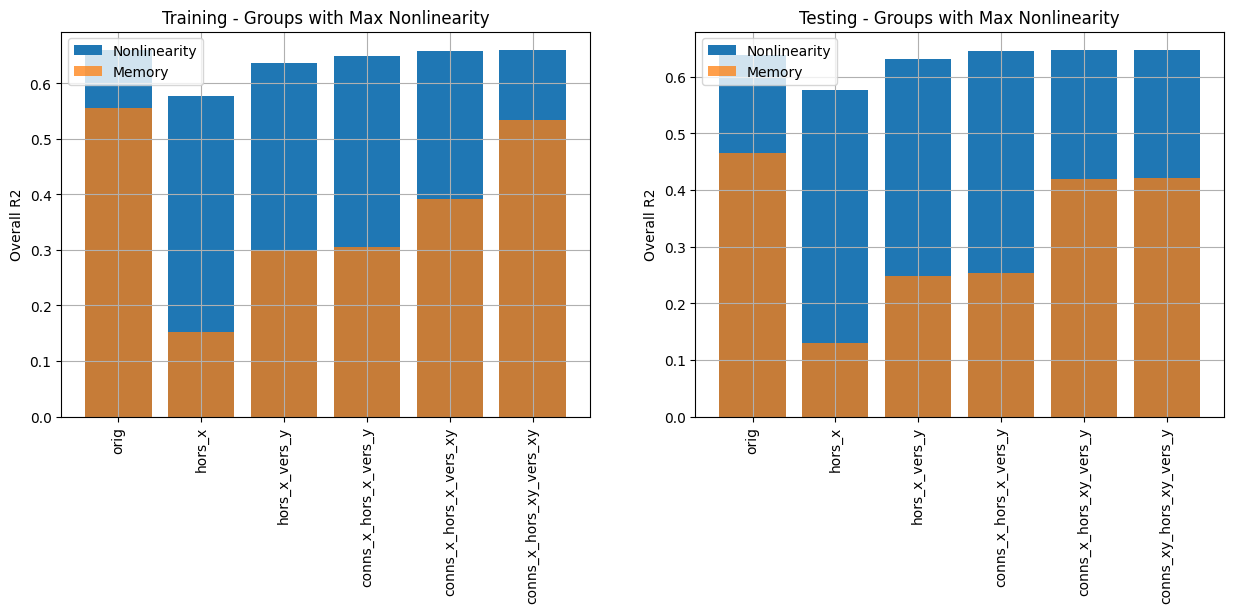

In [15]:
onl_list_train = [max_leg_train_dict[n][0] for n in max_leg_train_name_list]
oml_list_train = [max_leg_train_dict[n][1] for n in max_leg_train_name_list]
onl_list_test = [max_leg_test_dict[n][0] for n in max_leg_test_name_list]
oml_list_test = [max_leg_test_dict[n][1] for n in max_leg_test_name_list]

plt.figure(figsize=(15, 5))
plt.subplot(121)
labels_list = max_leg_train_name_list
plt.bar(labels_list, onl_list_train, label='Nonlinearity')
plt.bar(labels_list, oml_list_train, label='Memory', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Training - Groups with Max Nonlinearity')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.subplot(122)
labels_list = max_leg_test_name_list
plt.bar(labels_list, onl_list_test, label='Nonlinearity')
plt.bar(labels_list, oml_list_test, label='Memory', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Testing - Groups with Max Nonlinearity')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.show()

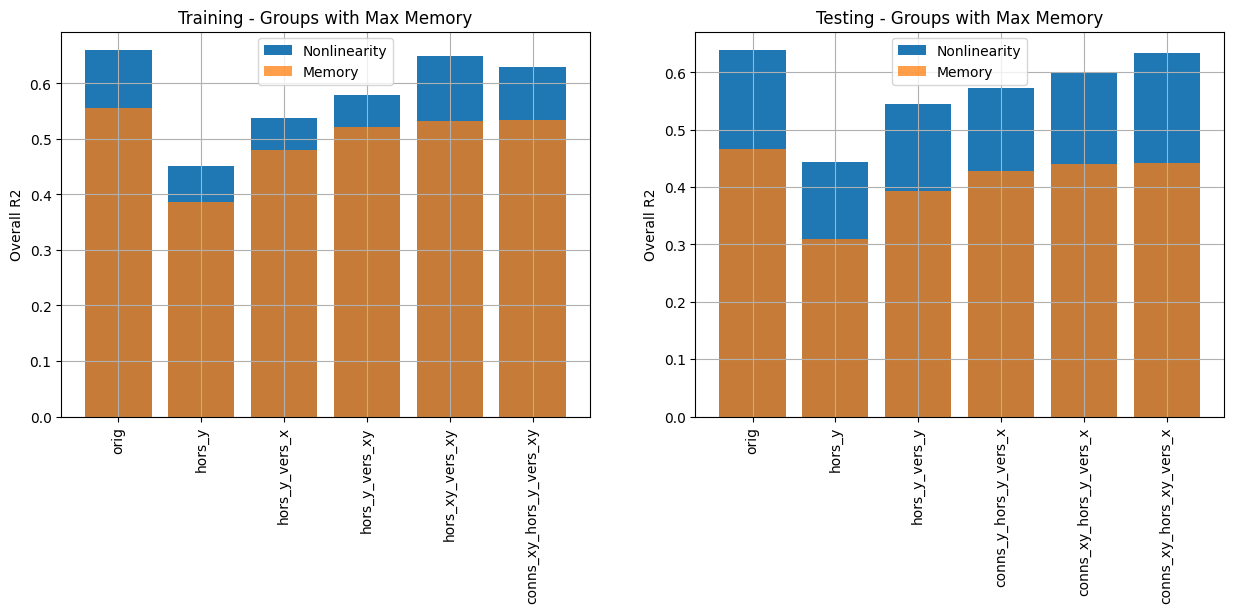

In [16]:
onl_list_train = [max_mem_train_dict[n][0] for n in max_mem_train_name_list]
oml_list_train = [max_mem_train_dict[n][1] for n in max_mem_train_name_list]
onl_list_test = [max_mem_test_dict[n][0] for n in max_mem_test_name_list]
oml_list_test = [max_mem_test_dict[n][1] for n in max_mem_test_name_list]

plt.figure(figsize=(15, 5))
plt.subplot(121)
labels_list = max_mem_train_name_list
plt.bar(labels_list, onl_list_train, label='Nonlinearity')
plt.bar(labels_list, oml_list_train, label='Memory', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Training - Groups with Max Memory')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.subplot(122)
labels_list = max_mem_test_name_list
plt.bar(labels_list, onl_list_test, label='Nonlinearity')
plt.bar(labels_list, oml_list_test, label='Memory', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Testing - Groups with Max Memory')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()

plt.show()

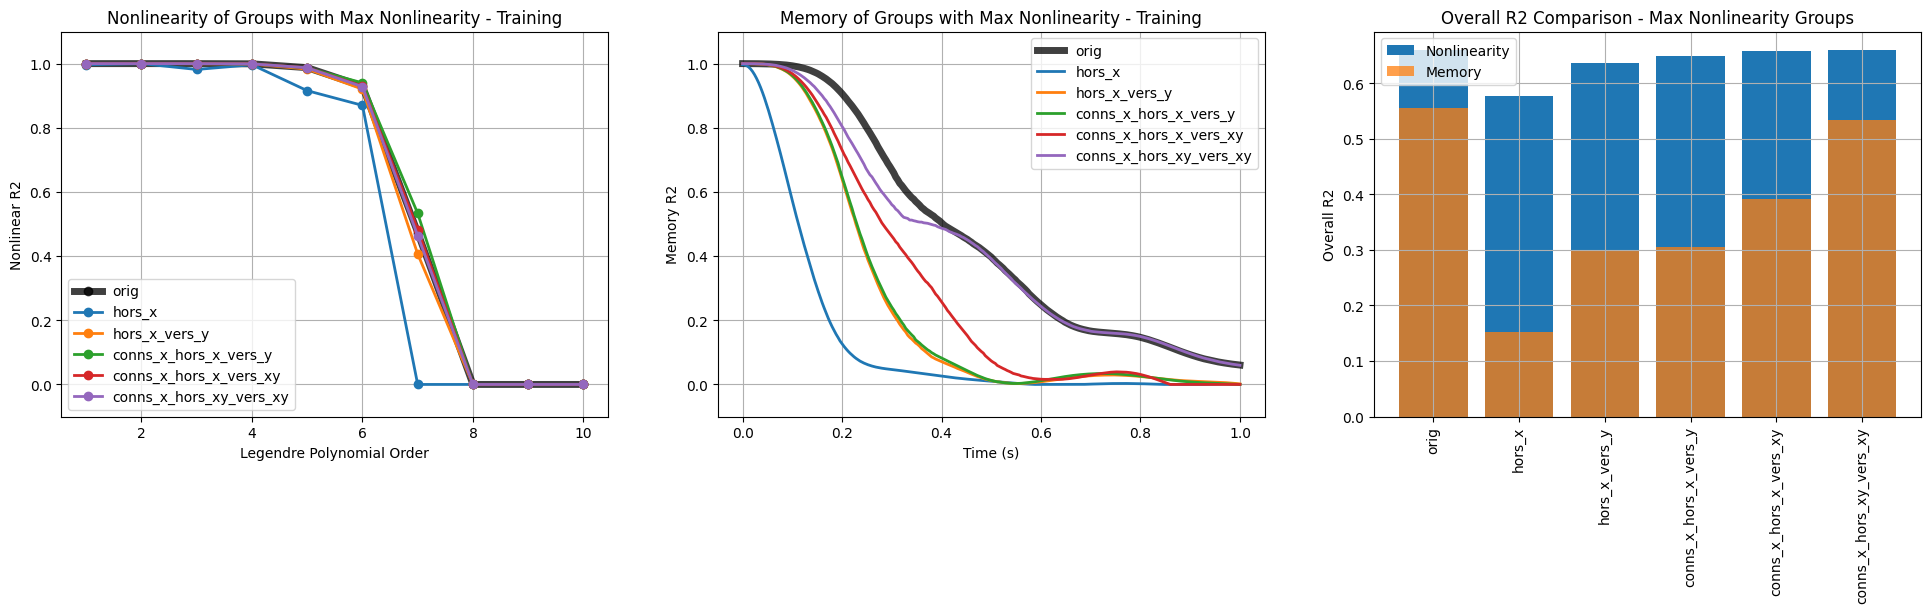

In [17]:
plt.figure(figsize=(24, 5))
plt.subplot(131)
plt.plot(leg_x, data_list_1[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
plt.plot(leg_x, data_list_1[idx_leg_11][leg][1], '-o', lw=2, label=max_leg_train_name_list[1])
plt.plot(leg_x, data_list_2[idx_leg_21][leg][1], '-o', lw=2, label=max_leg_train_name_list[2])
plt.plot(leg_x, data_list_3[idx_leg_31][leg][1], '-o', lw=2, label=max_leg_train_name_list[3])
plt.plot(leg_x, data_list_4[idx_leg_41][leg][1], '-o', lw=2, label=max_leg_train_name_list[4])
plt.plot(leg_x, data_list_5[idx_leg_51][leg][1], '-o', lw=2, label=max_leg_train_name_list[5])
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinearity of Groups with Max Nonlinearity - Training')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_list_1[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
plt.plot(mem_x, data_list_1[idx_leg_11][mem][1], lw=2, label=max_leg_train_name_list[1])
plt.plot(mem_x, data_list_2[idx_leg_21][mem][1], lw=2, label=max_leg_train_name_list[2])
plt.plot(mem_x, data_list_3[idx_leg_31][mem][1], lw=2, label=max_leg_train_name_list[3])
plt.plot(mem_x, data_list_4[idx_leg_41][mem][1], lw=2, label=max_leg_train_name_list[4])
plt.plot(mem_x, data_list_5[idx_leg_51][mem][1], lw=2, label=max_leg_train_name_list[5])
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory of Groups with Max Nonlinearity - Training')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = max_leg_train_name_list
onl_list = [max_leg_train_dict[n][0] for n in max_leg_train_name_list]
oml_list = [max_leg_train_dict[n][1] for n in max_leg_train_name_list]
plt.bar(labels_list, onl_list, label='Nonlinearity')
plt.bar(labels_list, oml_list, label='Memory', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Comparison - Max Nonlinearity Groups')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()
plt.show()

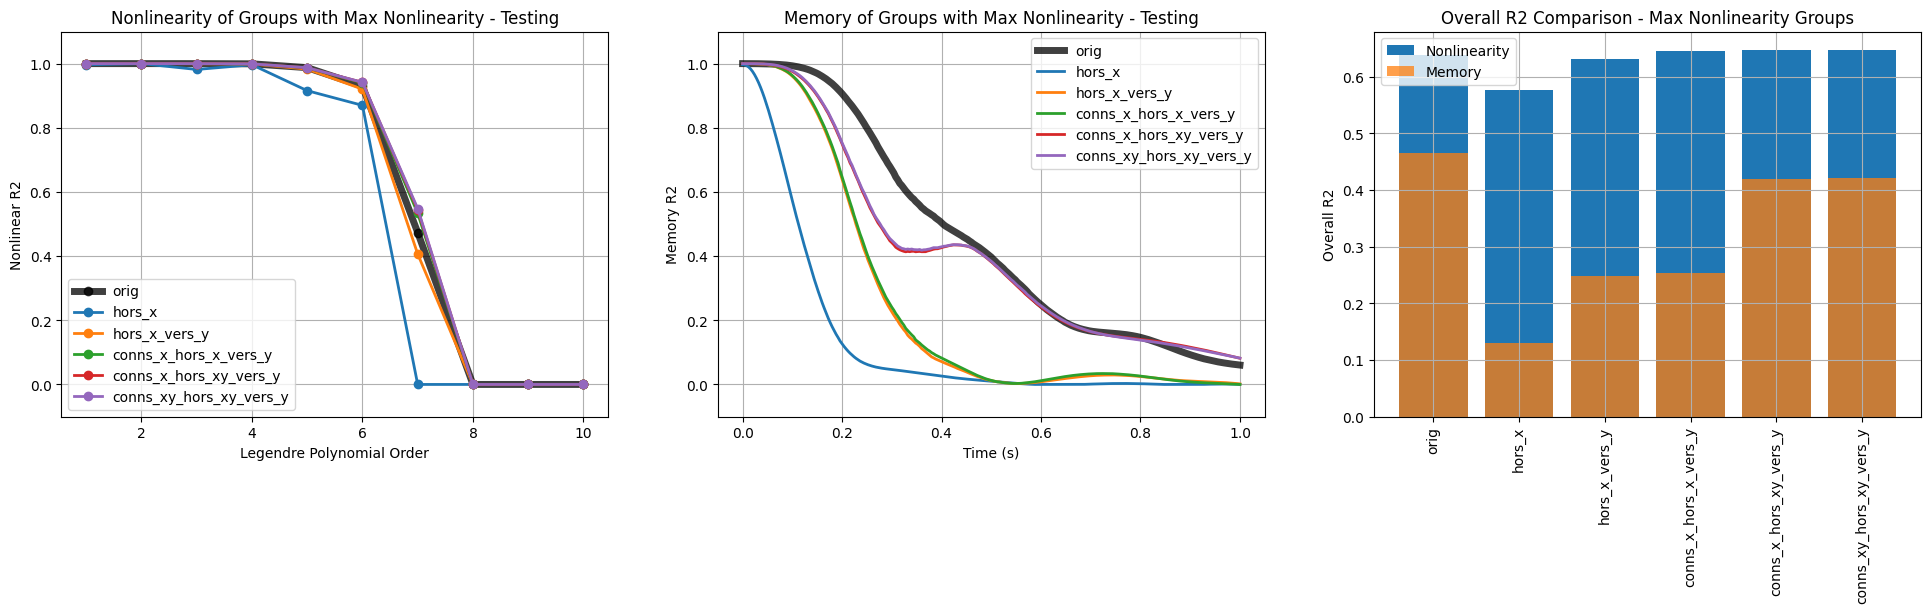

In [18]:
plt.figure(figsize=(24, 5))
plt.subplot(131)
plt.plot(leg_x, data_list_1[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
plt.plot(leg_x, data_list_1[idx_leg_12][leg][1], '-o', lw=2, label=max_leg_test_name_list[1])
plt.plot(leg_x, data_list_2[idx_leg_22][leg][1], '-o', lw=2, label=max_leg_test_name_list[2])
plt.plot(leg_x, data_list_3[idx_leg_32][leg][1], '-o', lw=2, label=max_leg_test_name_list[3])
plt.plot(leg_x, data_list_4[idx_leg_42][leg][1], '-o', lw=2, label=max_leg_test_name_list[4])
plt.plot(leg_x, data_list_5[idx_leg_52][leg][1], '-o', lw=2, label=max_leg_test_name_list[5])
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinearity of Groups with Max Nonlinearity - Testing')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_list_1[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
plt.plot(mem_x, data_list_1[idx_leg_12][mem][1], lw=2, label=max_leg_test_name_list[1])
plt.plot(mem_x, data_list_2[idx_leg_22][mem][1], lw=2, label=max_leg_test_name_list[2])
plt.plot(mem_x, data_list_3[idx_leg_32][mem][1], lw=2, label=max_leg_test_name_list[3])
plt.plot(mem_x, data_list_4[idx_leg_42][mem][1], lw=2, label=max_leg_test_name_list[4])
plt.plot(mem_x, data_list_5[idx_leg_52][mem][1], lw=2, label=max_leg_test_name_list[5])
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory of Groups with Max Nonlinearity - Testing')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = max_leg_test_name_list
onl_list = [max_leg_test_dict[n][0] for n in max_leg_test_name_list]
oml_list = [max_leg_test_dict[n][1] for n in max_leg_test_name_list]
plt.bar(labels_list, onl_list, label='Nonlinearity')
plt.bar(labels_list, oml_list, label='Memory', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Comparison - Max Nonlinearity Groups')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()
plt.show()

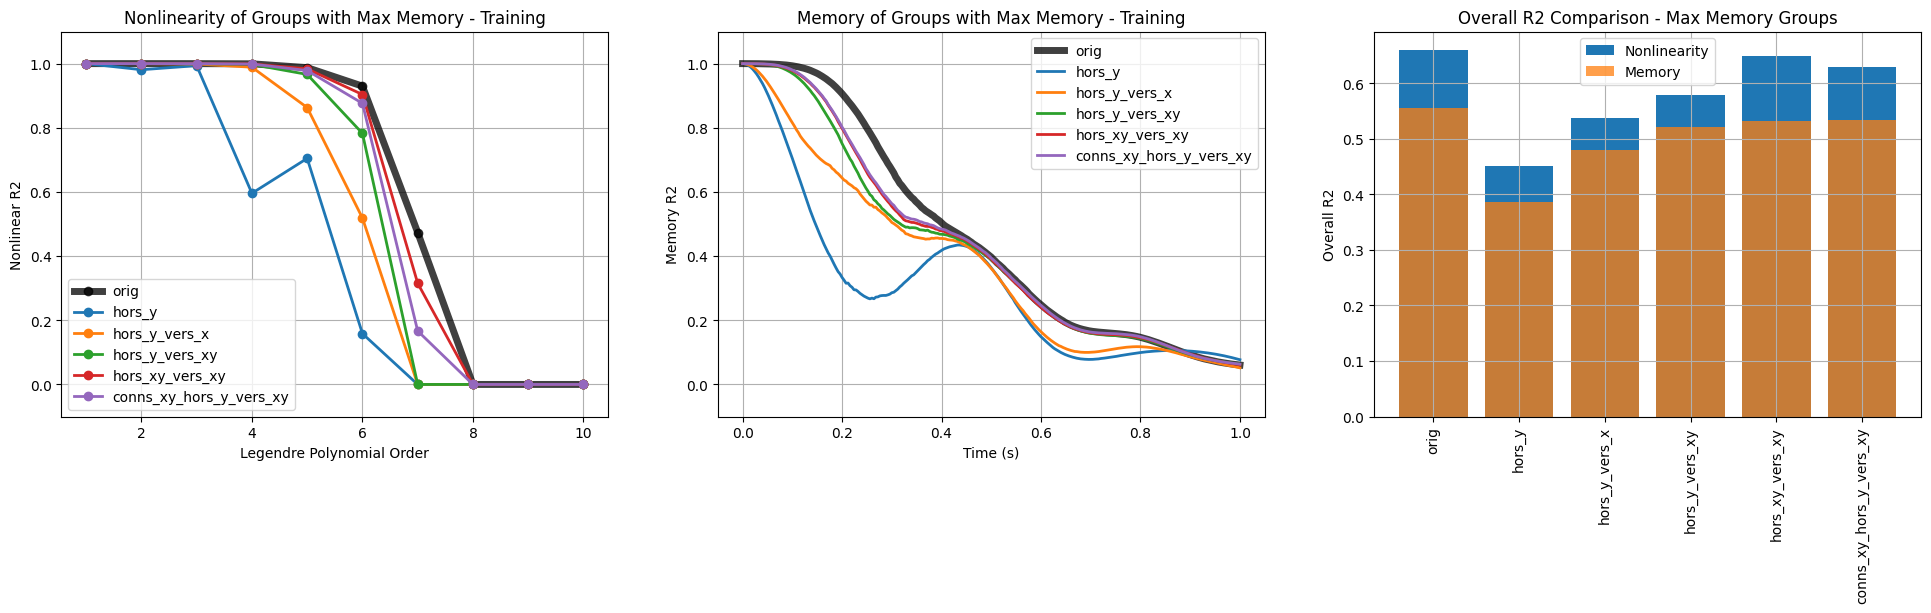

In [19]:
plt.figure(figsize=(24, 5))
plt.subplot(131)
plt.plot(leg_x, data_list_1[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
plt.plot(leg_x, data_list_1[idx_mem_11][leg][1], '-o', lw=2, label=max_mem_train_name_list[1])
plt.plot(leg_x, data_list_2[idx_mem_21][leg][1], '-o', lw=2, label=max_mem_train_name_list[2])
plt.plot(leg_x, data_list_3[idx_mem_31][leg][1], '-o', lw=2, label=max_mem_train_name_list[3])
plt.plot(leg_x, data_list_4[idx_mem_41][leg][1], '-o', lw=2, label=max_mem_train_name_list[4])
plt.plot(leg_x, data_list_5[idx_mem_51][leg][1], '-o', lw=2, label=max_mem_train_name_list[5])
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinearity of Groups with Max Memory - Training')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_list_1[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
plt.plot(mem_x, data_list_1[idx_mem_11][mem][1], lw=2, label=max_mem_train_name_list[1])
plt.plot(mem_x, data_list_2[idx_mem_21][mem][1], lw=2, label=max_mem_train_name_list[2])
plt.plot(mem_x, data_list_3[idx_mem_31][mem][1], lw=2, label=max_mem_train_name_list[3])
plt.plot(mem_x, data_list_4[idx_mem_41][mem][1], lw=2, label=max_mem_train_name_list[4])
plt.plot(mem_x, data_list_5[idx_mem_51][mem][1], lw=2, label=max_mem_train_name_list[5])
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory of Groups with Max Memory - Training')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = max_mem_train_name_list
onl_list = [max_mem_train_dict[n][0] for n in max_mem_train_name_list]
oml_list = [max_mem_train_dict[n][1] for n in max_mem_train_name_list]
plt.bar(labels_list, onl_list, label='Nonlinearity')
plt.bar(labels_list, oml_list, label='Memory', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Comparison - Max Memory Groups')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()
plt.show()

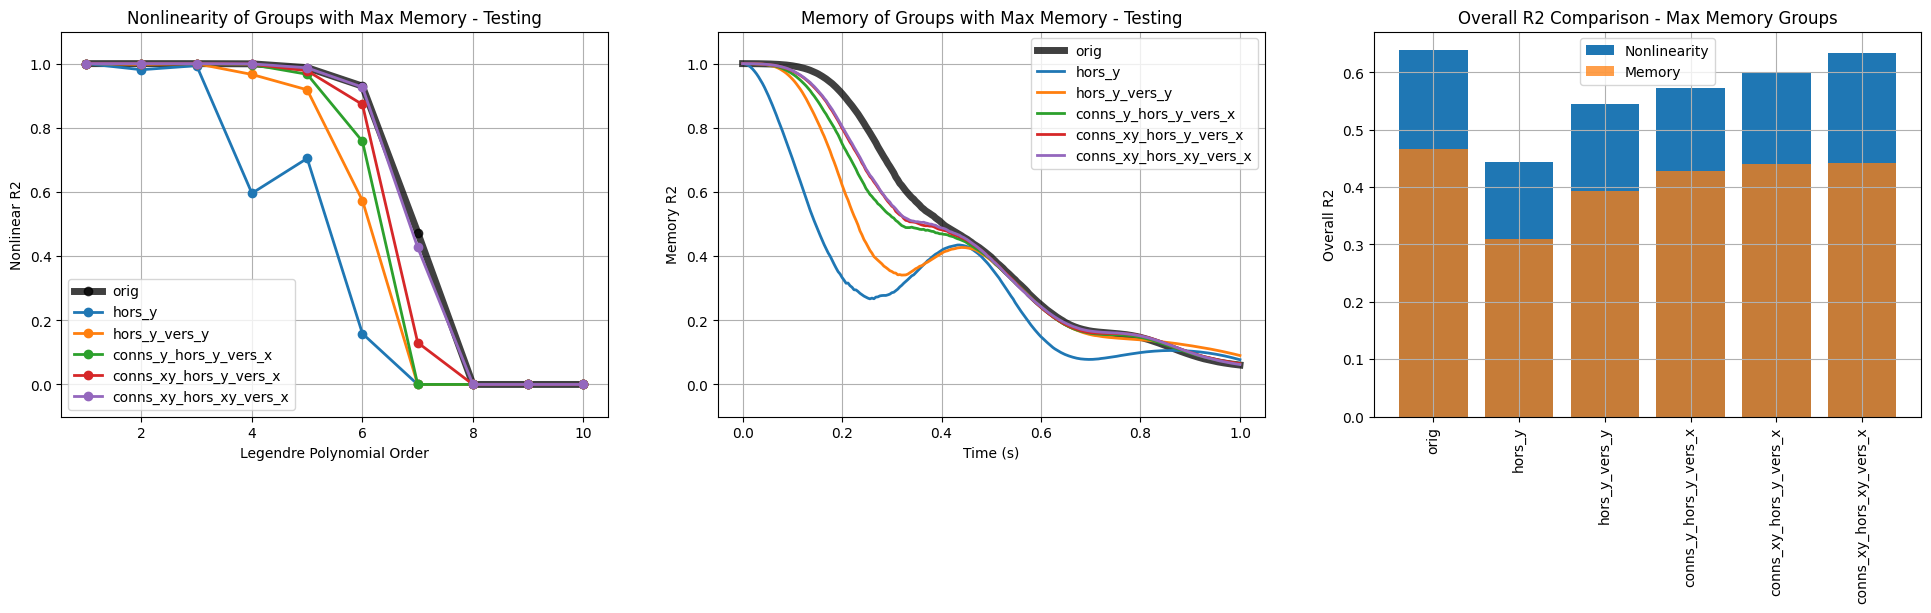

In [20]:
plt.figure(figsize=(24, 5))
plt.subplot(131)
plt.plot(leg_x, data_list_1[0][leg][1], '-o', lw=5, color='k', label='orig', alpha=0.75)
plt.plot(leg_x, data_list_1[idx_mem_12][leg][1], '-o', lw=2, label=max_mem_test_name_list[1])
plt.plot(leg_x, data_list_2[idx_mem_22][leg][1], '-o', lw=2, label=max_mem_test_name_list[2])
plt.plot(leg_x, data_list_3[idx_mem_32][leg][1], '-o', lw=2, label=max_mem_test_name_list[3])
plt.plot(leg_x, data_list_4[idx_mem_42][leg][1], '-o', lw=2, label=max_mem_test_name_list[4])
plt.plot(leg_x, data_list_5[idx_mem_52][leg][1], '-o', lw=2, label=max_mem_test_name_list[5])
plt.xlabel('Legendre Polynomial Order')
plt.ylabel('Nonlinear R2')
plt.title('Nonlinearity of Groups with Max Memory - Testing')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(132)
plt.plot(mem_x, data_list_1[0][mem][1], lw=5, color='k', label='orig', alpha=0.75)
plt.plot(mem_x, data_list_1[idx_mem_12][mem][1], lw=2, label=max_mem_test_name_list[1])
plt.plot(mem_x, data_list_2[idx_mem_22][mem][1], lw=2, label=max_mem_test_name_list[2])
plt.plot(mem_x, data_list_3[idx_mem_32][mem][1], lw=2, label=max_mem_test_name_list[3])
plt.plot(mem_x, data_list_4[idx_mem_42][mem][1], lw=2, label=max_mem_test_name_list[4])
plt.plot(mem_x, data_list_5[idx_mem_52][mem][1], lw=2, label=max_mem_test_name_list[5])
plt.xlabel('Time (s)')
plt.ylabel('Memory R2')
plt.title('Memory of Groups with Max Memory - Testing')
plt.ylim(-0.1, 1.1)
plt.grid()
plt.legend()
plt.subplot(133)
labels_list = max_mem_test_name_list
onl_list = [max_mem_test_dict[n][0] for n in max_mem_test_name_list]
oml_list = [max_mem_test_dict[n][1] for n in max_mem_test_name_list]
plt.bar(labels_list, onl_list, label='Nonlinearity')
plt.bar(labels_list, oml_list, label='Memory', alpha=0.75)
plt.ylabel('Overall R2')
plt.title('Overall R2 Comparison - Max Memory Groups')
# plt.ylim(0.2, 0.5)
plt.xticks(rotation=90)
plt.grid()
plt.legend()
plt.show()

### 6 GROUPS DROPPING OUTPUTS

In [21]:
# Load the data
folder = "op_groups_6x6_100s"
orig = np.load(f"{folder}/6by6_orig.npz", allow_pickle=True)
name_list = ['orig', 'hors_x_vers_y', 'hors_y_vers_x']

data_list = [orig]
for name in name_list[1:]:
    data = np.load(f"{folder}/6by6_ops_{name}.npz", allow_pickle=True)
    data_list.append(data)

leg_max_order = 10
max_time_back_seconds = 1
max_timesteps_back = np.rint(250*max_time_back_seconds).astype(int)
leg_x = np.linspace(1, leg_max_order, leg_max_order)
mem_x = np.linspace(0, max_time_back_seconds, max_timesteps_back+1)

leg = 'legendre_R2'
mem = 'memory_R2'

#### Old

In [ ]:
# Hors XY
hors_xy = data_list[1]
input_data = hors_xy['input_data']
output_data = hors_xy['output_data']

regressor = 'Rid'
test_size = 0.25
alpha = 1e-3
reeval = False

if reeval:
    # Nonlinearity testing
    leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output_data, leg_max_order, regressor, test_size, alpha)

    # Memory testing
    mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output_data, max_timesteps_back, regressor, test_size, alpha)

    onc_train_all = sum(leg_R2_train_list)/len(leg_R2_train_list)
    onc_test_all = sum(leg_R2_test_list)/len(leg_R2_test_list)

    omc_train_all = sum(mem_R2_train_list)/len(mem_R2_train_list)
    omc_test_all = sum(mem_R2_test_list)/len(mem_R2_test_list)
else:
    leg_R2_train = hors_xy[leg][0]
    leg_R2_test = hors_xy[leg][1]
    mem_R2_train = hors_xy[mem][0]
    mem_R2_test = hors_xy[mem][1]

    onc_train_all = sum(leg_R2_train)/len(leg_R2_train)
    onc_test_all = sum(leg_R2_test)/len(leg_R2_test)

    omc_train_all = sum(mem_R2_train)/len(mem_R2_train)
    omc_test_all = sum(mem_R2_test)/len(mem_R2_test)

print(f"Nonlinearity Training: {onc_train_all}, Testing: {onc_test_all}")
print(f"Memory Training: {omc_train_all}, Testing: {omc_test_all}")

Nonlinearity Training: 0.6362172879589589, Testing: 0.6308745108680293
Memory Training: 0.30053209229899436, Testing: 0.2490066001829993


In [8]:
import pandas as pd
x_idx = 0
y_idx = 0
output_reduction = pd.DataFrame(columns=['X', 'Y', 'leg_delta_train', 'leg_delta_test', 'mem_delta_train', 'mem_delta_test'])
j = 0
for i in range(0, output_data.shape[1], 2):
    if y_idx == 3 and x_idx == 3:
        leg_delta_train = np.nan
        leg_delta_test = np.nan
        mem_delta_train = np.nan
        mem_delta_test = np.nan

        output_reduction.at[j, 'X'] = x_idx
        output_reduction.at[j, 'Y'] = y_idx
        output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
        output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
        output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
        output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

        x_idx += 1

        if x_idx > 6:
            y_idx += 1
            x_idx = 0

        j += 1

    output = np.hstack([output_data[:, :i], output_data[:, i+2:]])
    # Nonlinearity testing
    leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output, leg_max_order, regressor, test_size, alpha)
    
    # Memory testing
    mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output, max_timesteps_back, regressor, test_size, alpha)

    onc_train = sum(leg_R2_train_list)/len(leg_R2_train_list)
    onc_test = sum(leg_R2_test_list)/len(leg_R2_test_list)

    omc_train = sum(mem_R2_train_list)/len(mem_R2_train_list)
    omc_test = sum(mem_R2_test_list)/len(mem_R2_test_list)

    leg_delta_train = onc_train_all - onc_train
    leg_delta_test = onc_test_all - onc_test

    mem_delta_train = omc_train_all - omc_train
    mem_delta_test = omc_test_all - omc_test

    output_reduction.at[j, 'X'] = x_idx
    output_reduction.at[j, 'Y'] = y_idx
    output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
    output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
    output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
    output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

    x_idx += 1

    if x_idx > 6:
        y_idx += 1
        x_idx = 0

    j += 1

KeyboardInterrupt: 

In [ ]:
output_reduction.to_csv(f'OutputReduction_alpha{alpha}_6x6_100s.csv', index=False)

In [ ]:
x_idx = 0
y_idx = 0
output_reduction = pd.DataFrame(columns=['Thread', 'leg_delta_train', 'leg_delta_test', 'mem_delta_train', 'mem_delta_test'])
j = 0
for i in range(0, output_data.shape[1], 14):
    # if y_idx == 3 and x_idx == 3:
    #     leg_delta_train = np.nan
    #     leg_delta_test = np.nan
    #     mem_delta_train = np.nan
    #     mem_delta_test = np.nan

    #     output_reduction.at[j, 'X'] = x_idx
    #     output_reduction.at[j, 'Y'] = y_idx
    #     output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
    #     output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
    #     output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
    #     output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

    #     x_idx += 1

    #     if x_idx > 6:
    #         y_idx += 1
    #         x_idx = 0

    #     j += 1

    if i == 3:
        output = np.hstack([output_data[:, :i], output_data[:, i+12:]])
    else:
        output = np.hstack([output_data[:, :i], output_data[:, i+14:]])

    # Nonlinearity testing
    leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output, leg_max_order, regressor, test_size, alpha)
    
    # Memory testing
    mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output, max_timesteps_back, regressor, test_size, alpha)

    onc_train = sum(leg_R2_train_list)/len(leg_R2_train_list)
    onc_test = sum(leg_R2_test_list)/len(leg_R2_test_list)

    omc_train = sum(mem_R2_train_list)/len(mem_R2_train_list)
    omc_test = sum(mem_R2_test_list)/len(mem_R2_test_list)

    leg_delta_train = onc_train_all - onc_train
    leg_delta_test = onc_test_all - onc_test

    mem_delta_train = omc_train_all - omc_train
    mem_delta_test = omc_test_all - omc_test

    output_reduction.at[j, 'Thread'] = j
    output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
    output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
    output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
    output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

    j += 1

In [ ]:
output_reduction.to_csv(f'OutputReductionThreadWise_alpha{alpha}_6x6_100s.csv', index=False)

#### Information Theory Hors X Vers Y

In [65]:
# Hors X Vers Y
hors_x_vers_y = data_list[0]
input_data = hors_x_vers_y['input_data']
input_data = -1 + ((input_data - np.min(input_data))/(np.max(input_data) - np.min(input_data))) * (1 - (-1))
output_data_orig = hors_x_vers_y['output_data']
output_data = output_data_orig / np.mean(output_data_orig, axis=0)
output_data /= np.std(output_data, axis=0)
scaler = preprocessing.StandardScaler().fit(output_data)
output_data = scaler.transform(output_data)

regressor = 'Rid'
test_size = 0.25
alpha = 1e-3
reeval = True

if reeval:
    # Nonlinearity testing
    leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output_data, leg_max_order, regressor, test_size, alpha)

    # Memory testing
    mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output_data, max_timesteps_back, regressor, test_size, alpha)

    onc_train_all = sum(leg_R2_train_list)/len(leg_R2_train_list)
    onc_test_all = sum(leg_R2_test_list)/len(leg_R2_test_list)

    omc_train_all = sum(mem_R2_train_list)/len(mem_R2_train_list)
    omc_test_all = sum(mem_R2_test_list)/len(mem_R2_test_list)
else:
    leg_R2_train = hors_x_vers_y[leg][0]
    leg_R2_test = hors_x_vers_y[leg][1]
    mem_R2_train = hors_x_vers_y[mem][0]
    mem_R2_test = hors_x_vers_y[mem][1]

    onc_train_all = sum(leg_R2_train)/len(leg_R2_train)
    onc_test_all = sum(leg_R2_test)/len(leg_R2_test)

    omc_train_all = sum(mem_R2_train)/len(mem_R2_train)
    omc_test_all = sum(mem_R2_test)/len(mem_R2_test)

print(f"Nonlinearity Training: {onc_train_all}, Testing: {onc_test_all}")
print(f"Memory Training: {omc_train_all}, Testing: {omc_test_all}")

Nonlinearity Training: 0.9331371763319865, Testing: 0.9383444758678999
Memory Training: 0.5560819383908554, Testing: 0.46719956244967814


In [66]:
print(f"Normalized output minimum: {np.min(output_data)}, maximum: {np.max(output_data)}")

Normalized output minimum: -18.483373901689085, maximum: 17.243585628927434


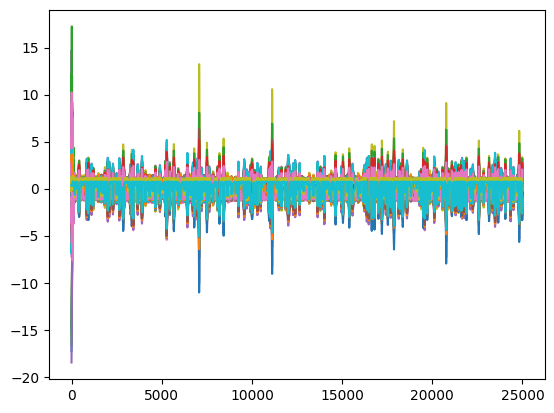

In [67]:
import matplotlib.pyplot as plt

plt.plot(output_data)
plt.show()

(25001, 240)


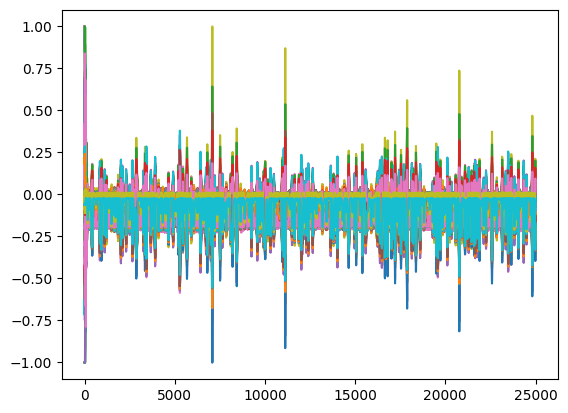

In [68]:
# Normalize the output between -1 to 1
op_norm = np.clip(output_data, -10, 12)
op_norm = -1 + ((op_norm - np.min(op_norm))/(np.max(op_norm) - np.min(op_norm))) * (1 - (-1))
print(op_norm.shape)

plt.plot(op_norm)
plt.show()

In [69]:
categories = [(-1, -0.5), (-0.5, -0.25), (-0.25, 0), (0, 0.25), (0.25, 0.5), (0.5, 1)]
fps = 250
sample_freq = 5
new_info_every = int(fps/sample_freq)

prob_dist_array = np.zeros((int(op_norm.shape[0]/new_info_every)+1, len(categories)))
i = 0

for t in range(0, op_norm.shape[0], new_info_every):
    samples = op_norm[t, :]
    for c in range(len(categories)):
        cat = categories[c]
        idx_cat = np.where(samples >= cat[0])[0]
        idx_cat = np.where(samples[idx_cat] < cat[1])[0]
        prob_dist_array[i, c] = len(idx_cat)/op_norm.shape[1]

    # print(t, samples, prob_dist_array[i, :])

    i += 1

prob_dist_array

array([[0.10833333, 0.025     , 0.55416667, 0.175     , 0.10416667,
        0.00833333],
       [0.00416667, 0.08333333, 0.71666667, 0.19166667, 0.00416667,
        0.        ],
       [0.        , 0.00416667, 0.8       , 0.19583333, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.775     , 0.225     , 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.60416667, 0.39583333, 0.        ,
        0.        ]])

In [71]:
(9/11)*np.log2(11/3) + (2/11)*np.log2(11/2)

1.9808259362290785

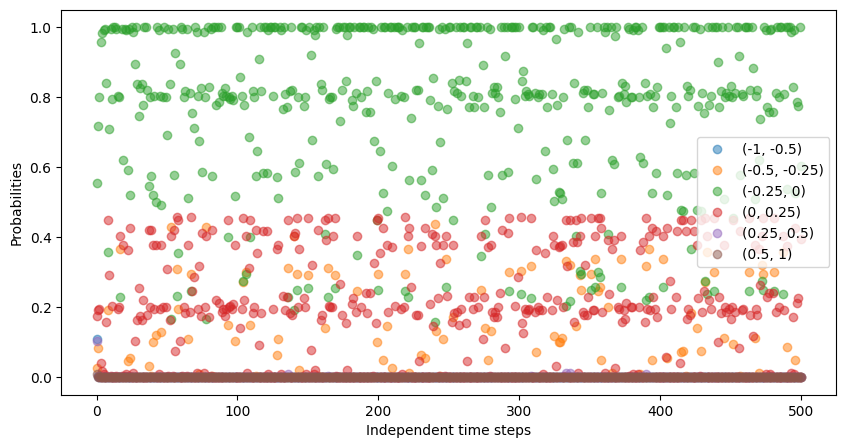

In [70]:
plt.figure(figsize=(10, 5))
for c in range(len(categories)):
    label = str(categories[c])
    plt.plot(prob_dist_array[:, c], 'o', label=label, alpha=0.5)
plt.xlabel('Independent time steps')
plt.ylabel('Probabilities')
plt.legend()
plt.show()

#### Information Theory Hors Y Vers X 

In [7]:
# Hors Y Vers X
hors_y_vers_x = data_list[2]
input_data = hors_y_vers_x['input_data']
output_data = hors_y_vers_x['output_data']

regressor = 'Rid'
test_size = 0.25
alpha = 1e-3
reeval = False

if reeval:
    # Nonlinearity testing
    leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output_data, leg_max_order, regressor, test_size, alpha)

    # Memory testing
    mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output_data, max_timesteps_back, regressor, test_size, alpha)

    onc_train_all = sum(leg_R2_train_list)/len(leg_R2_train_list)
    onc_test_all = sum(leg_R2_test_list)/len(leg_R2_test_list)

    omc_train_all = sum(mem_R2_train_list)/len(mem_R2_train_list)
    omc_test_all = sum(mem_R2_test_list)/len(mem_R2_test_list)
else:
    leg_R2_train = hors_y_vers_x[leg][0]
    leg_R2_test = hors_y_vers_x[leg][1]
    mem_R2_train = hors_y_vers_x[mem][0]
    mem_R2_test = hors_y_vers_x[mem][1]

    onc_train_all = sum(leg_R2_train)/len(leg_R2_train)
    onc_test_all = sum(leg_R2_test)/len(leg_R2_test)

    omc_train_all = sum(mem_R2_train)/len(mem_R2_train)
    omc_test_all = sum(mem_R2_test)/len(mem_R2_test)

print(f"Nonlinearity Training: {onc_train_all}, Testing: {onc_test_all}")
print(f"Memory Training: {omc_train_all}, Testing: {omc_test_all}")

Nonlinearity Training: 0.5383693725376577, Testing: 0.5369310396397138
Memory Training: 0.4794431787157981, Testing: 0.378098064619126


In [ ]:
# x_idx = 0
# y_idx = 0
# output_reduction = pd.DataFrame(columns=['X_pos', 'Y_pos', 'X_idx', 'Y_idx', 'leg_delta_train', 'leg_delta_test', 'mem_delta_train', 'mem_delta_test'])
# output = output_data / np.mean(output_data, axis=0)
# output /= np.std(output_data, axis=0)
# j = 0
# for i in range(0, int(output_data.shape[1]/2)):
#     if y_idx == 3 and x_idx == 3:
#         leg_delta_train = np.nan
#         leg_delta_test = np.nan
#         mem_delta_train = np.nan
#         mem_delta_test = np.nan

#         output_reduction.at[j, 'X_pos'] = 0
#         output_reduction.at[j, 'Y_pos'] = y_idx
#         output_reduction.at[j, 'X_idx'] = x_idx
#         output_reduction.at[j, 'Y_idx'] = y_idx
#         output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
#         output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
#         output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
#         output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

#         x_idx += 1

#         if x_idx > 6:
#             y_idx += 1
#             x_idx = 0

#         j += 1

#     output = np.hstack([output[:, :i], output[:, i+1:]])
#     # Nonlinearity testing
#     leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output, leg_max_order, regressor, test_size, alpha)
    
#     # Memory testing
#     mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output, max_timesteps_back, regressor, test_size, alpha)

#     onc_train = sum(leg_R2_train_list)/len(leg_R2_train_list)
#     onc_test = sum(leg_R2_test_list)/len(leg_R2_test_list)

#     omc_train = sum(mem_R2_train_list)/len(mem_R2_train_list)
#     omc_test = sum(mem_R2_test_list)/len(mem_R2_test_list)

#     leg_delta_train = onc_train_all - onc_train
#     leg_delta_test = onc_test_all - onc_test

#     mem_delta_train = omc_train_all - omc_train
#     mem_delta_test = omc_test_all - omc_test

#     output_reduction.at[j, 'X_pos'] = output_data[0, i]
#     output_reduction.at[j, 'Y_pos'] = y_idx
#     output_reduction.at[j, 'X_idx'] = x_idx
#     output_reduction.at[j, 'Y_idx'] = y_idx
#     output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
#     output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
#     output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
#     output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

#     x_idx += 1

#     if x_idx > 6:
#         y_idx += 1
#         x_idx = 0

#     j += 1

# print(j)

42


In [ ]:
# # j -= 1
# x_idx = 0
# y_idx = 0
# for i in range(int(output_data.shape[1]/2), output_data.shape[1]):
#     # if y_idx == 3 and x_idx == 3:
#     #     leg_delta_train = np.nan
#     #     leg_delta_test = np.nan
#     #     mem_delta_train = np.nan
#     #     mem_delta_test = np.nan

#     #     output_reduction.at[j, 'X'] = x_idx
#     #     output_reduction.at[j, 'Y'] = y_idx
#     #     output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
#     #     output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
#     #     output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
#     #     output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

#     #     y_idx += 1

#     #     if y_idx > 6:
#     #         x_idx += 1
#     #         y_idx = 0

#     #     j += 1

#     output = np.hstack([output[:, :i], output[:, i+1:]])
#     # Nonlinearity testing
#     leg_capacity_train_list, leg_capacity_test_list, leg_R2_train_list, leg_R2_test_list = nonlinearity_testing(input_data, output, leg_max_order, regressor, test_size, alpha)
    
#     # Memory testing
#     mem_capacity_train_list, mem_capacity_test_list, mem_R2_train_list, mem_R2_test_list = memory_testing(input_data, output, max_timesteps_back, regressor, test_size, alpha)

#     onc_train = sum(leg_R2_train_list)/len(leg_R2_train_list)
#     onc_test = sum(leg_R2_test_list)/len(leg_R2_test_list)

#     omc_train = sum(mem_R2_train_list)/len(mem_R2_train_list)
#     omc_test = sum(mem_R2_test_list)/len(mem_R2_test_list)

#     leg_delta_train = onc_train_all - onc_train
#     leg_delta_test = onc_test_all - onc_test

#     mem_delta_train = omc_train_all - omc_train
#     mem_delta_test = omc_test_all - omc_test

#     output_reduction.at[j, 'X_pos'] = x_idx
#     output_reduction.at[j, 'Y_pos'] = output_data[0, i]
#     output_reduction.at[j, 'X_idx'] = x_idx
#     output_reduction.at[j, 'Y_idx'] = y_idx
#     output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
#     output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
#     output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
#     output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

#     y_idx += 1

#     if y_idx > 6:
#         x_idx += 1
#         y_idx = 0

#     j += 1

In [ ]:
# j = 24
# leg_delta_train = np.nan
# leg_delta_test = np.nan
# mem_delta_train = np.nan
# mem_delta_test = np.nan

# output_reduction.at[j, 'X_pos'] = 0
# output_reduction.at[j, 'Y_pos'] = 3
# output_reduction.at[j, 'X_idx'] = 3
# output_reduction.at[j, 'Y_idx'] = 3
# output_reduction.at[j, 'leg_delta_train'] = leg_delta_train
# output_reduction.at[j, 'leg_delta_test'] = leg_delta_test
# output_reduction.at[j, 'mem_delta_train'] = mem_delta_train
# output_reduction.at[j, 'mem_delta_test'] = mem_delta_test

# output_reduction

,X_pos,Y_pos,X_idx,Y_idx,leg_delta_train,leg_delta_test,mem_delta_train,mem_delta_test,X,Y
0,-220.0,0,0,0,0.094619,0.087629,0.148397,0.131822,NaN,NaN
1,-150.0,0,1,0,0.094627,0.087477,0.148408,0.13183,NaN,NaN
2,-70.0,0,2,0,0.094633,0.087485,0.148415,0.131839,NaN,NaN
3,0.0,0,3,0,0.094645,0.087659,0.148418,0.131842,NaN,NaN
4,70.0,0,4,0,0.094648,0.087661,0.148419,0.131843,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
79,6,-70.0,6,1,0.159059,0.150603,0.181199,0.151493,NaN,NaN
80,6,0.0,6,2,0.159059,0.150603,0.181199,0.151493,NaN,NaN
81,6,70.0,6,3,0.159059,0.150603,0.181199,0.151493,NaN,NaN
82,6,150.0,6,4,0.159059,0.150603,0.181199,0.151493,NaN,NaN


## Information Theory for original data

In [3]:
from sklearn.feature_selection import mutual_info_regression

data = np.load('6by6_orig.npz', allow_pickle=True)
input_data = data['input_data']
output_data = data['output_data']

print(input_data.shape, output_data.shape)

(25001, 1) (25001, 240)


#### MI between input and outputs

In [4]:
mi_ip_op = mutual_info_regression(output_data, input_data[:, 0], discrete_features=False)
print(mi_ip_op.shape)

(240,)


Connections from 0 to 72, Horizontals from 72 to 154, Verticals from 154 to 240


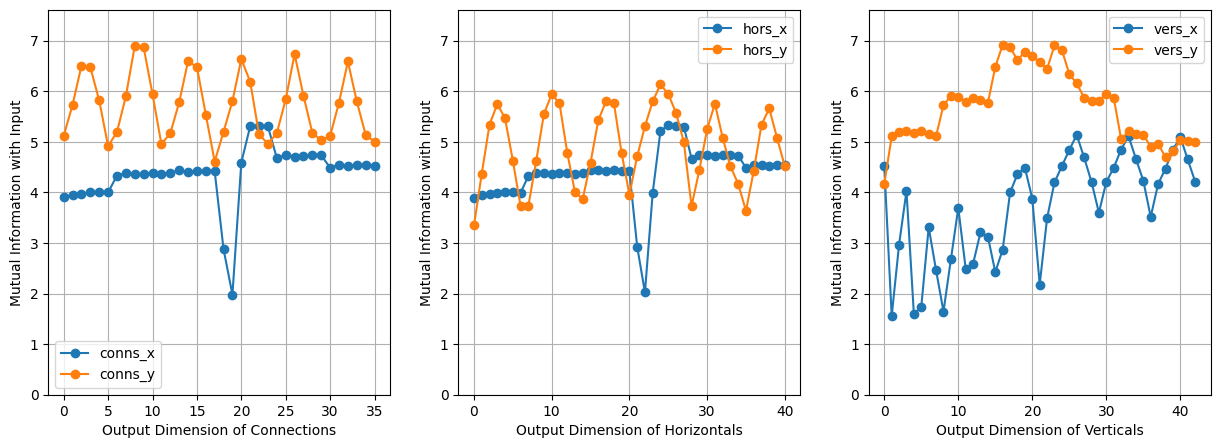

In [5]:
conns_end = 6*6*2
hors_end = conns_end + (7*6 - 1)*2
vers_end = mi_ip_op.shape[0]
print(f'Connections from 0 to {conns_end}, Horizontals from {conns_end} to {hors_end}, Verticals from {hors_end} to {vers_end}')
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.plot(mi_ip_op[0:conns_end:2], '-o', label='conns_x')
plt.plot(mi_ip_op[1:conns_end:2], '-o', label='conns_y')
plt.xlabel('Output Dimension of Connections')
plt.ylabel('Mutual Information with Input')
plt.grid()
plt.legend()
plt.ylim(0, np.max(mi_ip_op)*1.1)
plt.subplot(132)
plt.plot(mi_ip_op[conns_end:hors_end:2], '-o', label='hors_x')
plt.plot(mi_ip_op[conns_end+1:hors_end:2], '-o', label='hors_y')
plt.xlabel('Output Dimension of Horizontals')
plt.ylabel('Mutual Information with Input')
plt.grid()
plt.legend()
plt.ylim(0, np.max(mi_ip_op)*1.1)
plt.subplot(133)
plt.plot(mi_ip_op[hors_end:vers_end:2], '-o', label='vers_x')
plt.plot(mi_ip_op[hors_end+1:vers_end:2], '-o', label='vers_y')
plt.xlabel('Output Dimension of Verticals')
plt.ylabel('Mutual Information with Input')
plt.grid()
plt.legend()
plt.ylim(0, np.max(mi_ip_op)*1.1)
plt.show()

#### MI among outputs

In [6]:
mi_op_op = np.zeros((output_data.shape[1], output_data.shape[1]))
for i in range(output_data.shape[1]):
    mi_op_op[i, :] = mutual_info_regression(output_data, output_data[:, i], discrete_features=False)

plt.figure(figsize=(8, 6))
plt.imshow(mi_op_op, cmap='hot', interpolation='nearest')
plt.colorbar(label='Mutual Information between Outputs')
plt.title('Mutual Information between Output Dimensions')
plt.xlabel('Output Dimension')
plt.ylabel('Output Dimension')
plt.show()

KeyboardInterrupt: 

In [ ]:
mi_conns_x = mi_ip_op[0:conns_end:2, :]
mi_conns_y = mi_ip_op[1:conns_end:2, :]
mi_hors_x = mi_ip_op[conns_end:hors_end:2, :]
mi_hors_y = mi_ip_op[conns_end+1:hors_end:2, :]
mi_vers_x = mi_ip_op[hors_end:vers_end:2, :]
mi_vers_y = mi_ip_op[hors_end+1:vers_end:2, :]
plt.figure(figsize=(15, 10))
plt.subplot(231)
plt.imshow(mi_conns_x, cmap='hot', interpolation='nearest')
plt.colorbar(label='MI between Outputs and Conns X')
plt.title('MI between Outputs and Connections X')
plt.xlabel('Connections X Output Dimension')
plt.ylabel('Output Dimension')
plt.subplot(232)
plt.imshow(mi_conns_y, cmap='hot', interpolation='nearest')
plt.colorbar(label='MI between Outputs and Conns Y')
plt.title('MI between Outputs and Connections Y')
plt.xlabel('Connections Y Output Dimension')
plt.ylabel('Output Dimension')
plt.subplot(233)
plt.imshow(mi_hors_x, cmap='hot', interpolation='nearest')
plt.colorbar(label='MI between Outputs and Hors X')
plt.title('MI between Outputs and Horses X')
plt.xlabel('Horses X Output Dimension')
plt.ylabel('Output Dimension')
plt.subplot(234)
plt.imshow(mi_hors_y, cmap='hot', interpolation='nearest')
plt.colorbar(label='MI between Outputs and Hors Y')
plt.title('MI between Outputs and Horses Y')
plt.xlabel('Horses Y Output Dimension')
plt.ylabel('Output Dimension')
plt.subplot(235)
plt.imshow(mi_vers_x, cmap='hot', interpolation='nearest')
plt.colorbar(label='MI between Outputs and Vers X')
plt.title('MI between Outputs and Verticals X')
plt.xlabel('Verticals X Output Dimension')
plt.ylabel('Output Dimension')
plt.subplot(236)
plt.imshow(mi_vers_y, cmap='hot', interpolation='nearest')
plt.colorbar(label='MI between Outputs and Vers Y')
plt.title('MI between Outputs and Verticals Y')
plt.xlabel('Verticals Y Output Dimension')
plt.ylabel('Output Dimension')
plt.show()